## figure out normalization and difference from last time...


In [1]:
print('testing new commit from mac')

testing new commit from mac


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
from numba import njit
# from scipy import odr
# from scipy.special import voigt_profile
from scipy.optimize import curve_fit
from scipy import stats as st
import time
import math

In [3]:
# os.chdir('F:/LANL/processed_data/')
# processedfolder = 'F:/LANL/processed_data/'

os.chdir('F:/LANL/')
# os.chdir('/mnt/c/Users/gabeo/Desktop/analysis_temp/')
root = os.getcwd()

processedfolder = '/processed_data/'

In [4]:
run_start = 12950
run_end   = 13604

base_path = root + processedfolder

folderslist = []
runslist_D = []
runslist_U = []

print("\n=== Discovering asym runs ===")

for folder in sorted(os.listdir(base_path)):
    if not folder.startswith("runs"):
        continue
    # parse folder range
    try:
        f_start, f_end = folder.replace("runs", "").split("-")
        f_start, f_end = int(f_start), int(f_end)
    except:
        print(f"Skipping {folder}")
        continue
    # skip irrelevant folders
    if f_end < run_start or f_start > run_end:
        continue

    fpath = os.path.join(base_path, folder)
    asymD_path = os.path.join(fpath, "asym_D")
    asymU_path = os.path.join(fpath, "asym_U")

    if not os.path.exists(asymD_path) or not os.path.exists(asymU_path):
        continue

    runs_D = []
    runs_U = []

    # --- D files ---
    for fname in sorted(os.listdir(asymD_path)):
        if fname.endswith(".h5"):
            run = int(fname.split('_')[0])
            if run_start <= run <= run_end:
                runs_D.append(fname)
    # --- U files ---
    for fname in sorted(os.listdir(asymU_path)):
        if fname.endswith(".h5"):
            run = int(fname.split('_')[0])
            if run_start <= run <= run_end:
                runs_U.append(fname)

    if len(runs_D) == 0:
        continue

    print(f"{folder}: {len(runs_D)} runs")

    folderslist.append(folder + '/')
    runslist_D.append(sorted(runs_D))
    runslist_U.append(sorted(runs_U))

print("\nTotal folders used:", len(folderslist))


=== Discovering asym runs ===
runs12686-13279: 197 runs
runs13280-13563: 123 runs
runs13564-13604: 41 runs

Total folders used: 3


In [5]:
## allows h5 loads to be easier...
flatrunslist_D = [run for folder in runslist_D for run in folder]
flatrunslist_U = [run for folder in runslist_U for run in folder]

foldersflat = []
for i in range(len(folderslist)):
    foldersflat += [folderslist[i]] * len(runslist_D[i])

print(len(foldersflat))

361


In [6]:
# --- Find common + mismatched runs between D and U ---

common_runs_all = []

print("\n=== Checking D vs U consistency ===")

for f in range(len(folderslist)):
    folder = folderslist[f]
    runs_D = runslist_D[f]
    runs_U = runslist_U[f]
    # --- extract run numbers ONLY ---
    runs_D_nums = [r.split('_')[0] for r in runs_D]
    runs_U_nums = [r.split('_')[0] for r in runs_U]

    # print("\nRAW FILES:")
    print("D example:", runs_D[:5])
    print("U example:", runs_U[:5])
    # print("Parsed run numbers:")
    # print("D:", runs_D_nums[:5])
    # print("U:", runs_U_nums[:5])

    set_D = set(runs_D_nums)
    set_U = set(runs_U_nums)
    common = sorted(list(set_D & set_U))
    only_D = sorted(list(set_D - set_U))
    only_U = sorted(list(set_U - set_D))

    print(f"\nFolder: {folder}")
    print(f"  D runs: {len(set_D)} | U runs: {len(set_U)} | Common: {len(common)}")
    if only_D:
        print(f"  ⚠ Runs in D but NOT in U ({len(only_D)}):")
        print(f"    {only_D[:10]} ...")  # truncate so it doesn't explode output
    if only_U:
        print(f"  ⚠ Runs in U but NOT in D ({len(only_U)}):")
        print(f"    {only_U[:10]} ...")
    common_runs_all.append(common)

# --- flatten ---
common_runs = sorted([run for sublist in common_runs_all for run in sublist])

print("\n=== Summary ===")
print("Total common runs:", len(common_runs))
print("First few:", common_runs[:10])
print("Last few:", common_runs[-10:])

numruns_tot_D = len(flatrunslist_D) ## U and D should be the same? ## should change to num pulses maybe
numruns_tot_U = len(flatrunslist_U) ## 
if numruns_tot_D != numruns_tot_U:
    emessage = ('# upstream files and downstream files are not the same!')
    # logger.error(run_num + emessage)
    raise Exception(emessage)


=== Checking D vs U consistency ===
D example: ['12952_D.h5', '12955_D.h5', '12959_D.h5', '12960_D.h5', '12962_D.h5']
U example: ['12952_U.h5', '12955_U.h5', '12959_U.h5', '12960_U.h5', '12962_U.h5']

Folder: runs12686-13279/
  D runs: 197 | U runs: 197 | Common: 197
D example: ['13292_D.h5', '13296_D.h5', '13297_D.h5', '13309_D.h5', '13333_D.h5']
U example: ['13292_U.h5', '13296_U.h5', '13297_U.h5', '13309_U.h5', '13333_U.h5']

Folder: runs13280-13563/
  D runs: 123 | U runs: 123 | Common: 123
D example: ['13564_D.h5', '13565_D.h5', '13566_D.h5', '13567_D.h5', '13568_D.h5']
U example: ['13564_U.h5', '13565_U.h5', '13566_U.h5', '13567_U.h5', '13568_U.h5']

Folder: runs13564-13604/
  D runs: 41 | U runs: 41 | Common: 41

=== Summary ===
Total common runs: 361
First few: ['12952', '12955', '12959', '12960', '12962', '12987', '12989', '12990', '12992', '12993']
Last few: ['13595', '13596', '13597', '13598', '13599', '13600', '13601', '13602', '13603', '13604']


In [7]:
## load in the x array. Also helps in determining sizes
## NO 6LI FOR THESE HDF5 FILES
asymDendname = '/asym_D/'
asymUendname = '/asym_U/'

channels_all = []
folderpath = root+processedfolder+folderslist[0]
with h5py.File(folderpath+asymDendname+runslist_D[0][0], 'r') as f: ## new arr_sizer
    channels_D = list(f.keys())
    channels_all.append(channels_D[:-1])
    numchannels = len(channels_D)-1
    dataset = f[channels_D[-1]]   ## this is the xs dataset
#     xs = np.array(dataset)*1e-6 ## now in ms
#     numpoints = len(xs)
    f.close()
    
with h5py.File(folderpath+asymUendname+runslist_U[0][0], 'r') as f: ## new arr_sizer
    channels_U = list(f.keys())
    channels_all=np.append(channels_all, channels_U[:-1])
#     channels_all.append(channels[:-1])
    numchannels = len(channels_U)-1
    dataset = f[channels_U[-1]]   ## this is the xs dataset
    xs = np.array(dataset)*1e-6 ## now in ms
    numpoints = len(xs)
    f.close()
# print(channels_all)
# channels_all = np.asarray(channels_all, dtype=object)
# print(channels_all)
# channels_all = channels_all.flatten()
print(numruns_tot_D,numchannels,numpoints)
# print(data.shape)
# print(data[seq][0][0])
# print(channels_all[:])
print(channels_all[-1])
print(len(xs))

print(channels_D)
print(channels_U)
print(channels_all)

# print(channels_all.flatten())
# print(data)

361 13 8992
ch_24
8992
['ch_00', 'ch_01', 'ch_02', 'ch_03', 'ch_04', 'ch_05', 'ch_06', 'ch_07', 'ch_08', 'ch_09', 'ch_10', 'ch_11', 'ch_24', 'xs ']
['ch_12', 'ch_13', 'ch_14', 'ch_15', 'ch_16', 'ch_17', 'ch_18', 'ch_19', 'ch_20', 'ch_21', 'ch_22', 'ch_23', 'ch_24', 'xs ']
['ch_00' 'ch_01' 'ch_02' 'ch_03' 'ch_04' 'ch_05' 'ch_06' 'ch_07' 'ch_08'
 'ch_09' 'ch_10' 'ch_11' 'ch_24' 'ch_12' 'ch_13' 'ch_14' 'ch_15' 'ch_16'
 'ch_17' 'ch_18' 'ch_19' 'ch_20' 'ch_21' 'ch_22' 'ch_23' 'ch_24']


In [8]:
# ## loads on/off added pulses. not needed for asym based on multiplicative factor ##
numsequences = []
# run_ampasym_D = []
# run_ampasym_U = []
run_rawasym_D = []
run_rawasym_U = []
# totnumchan = len(run_asyms_D[0])+len(run_asyms_U_noLi[0])

folderpath = root+processedfolder+folderslist[0]  ## generalize this to all folders

for i in range(0,len(runslist_D)):
    runname = folderpath+asymDendname+runslist_D[0][i]  ##[0] indicates the first folder
    print(runname)
    with h5py.File(runname, 'r') as f:
        # print("Keys: %s" % f.keys())
        channels = list(f.keys())
        numchannels = len(channels)-1
        num_seq = f.attrs.get('sequences')
        numsequences.append(num_seq)
        # runamp = []
        runraw = []
#             print(str(np.char.zfill(str(chan_enab[i]),2)))
#             dataset = f['ch '+str(np.char.zfill(str(chan_enab[i]), 2))]
        for i in range(0,numchannels):
            chsubgrp = f[channels[i]]  ##change this to match channels[i]
            print(chsubgrp)
# #             print(list(chsubgrp.attrs))
#             print((chsubgrp.attrs.get('asym_amp')))
            # asym_amp_data = np.array(chsubgrp.attrs.get('asym_amp'))
            # print(asym_amp_data[0])
            asym_raw_chdataset = np.array(chsubgrp['asym_raw'])
#             print(asym_raw_chdataset)
            # runamp.append(asym_amp_data)
            runraw.append(asym_raw_chdataset)
        # run_ampasym_D.append(runamp)
        run_rawasym_D.append(runraw)
        f.close()
#         folderpath = root+processedfolder+folderslist[0]  ## generalize this to all folders


F:\LANL/processed_data/runs12686-13279//asym_D/12952_D.h5
<HDF5 group "/ch_00" (3 members)>
<HDF5 group "/ch_01" (3 members)>
<HDF5 group "/ch_02" (3 members)>
<HDF5 group "/ch_03" (3 members)>
<HDF5 group "/ch_04" (3 members)>
<HDF5 group "/ch_05" (3 members)>
<HDF5 group "/ch_06" (3 members)>
<HDF5 group "/ch_07" (3 members)>
<HDF5 group "/ch_08" (3 members)>
<HDF5 group "/ch_09" (3 members)>
<HDF5 group "/ch_10" (3 members)>
<HDF5 group "/ch_11" (3 members)>
<HDF5 group "/ch_24" (1 members)>
F:\LANL/processed_data/runs12686-13279//asym_D/12955_D.h5
<HDF5 group "/ch_00" (3 members)>
<HDF5 group "/ch_01" (3 members)>
<HDF5 group "/ch_02" (3 members)>
<HDF5 group "/ch_03" (3 members)>
<HDF5 group "/ch_04" (3 members)>
<HDF5 group "/ch_05" (3 members)>
<HDF5 group "/ch_06" (3 members)>
<HDF5 group "/ch_07" (3 members)>
<HDF5 group "/ch_08" (3 members)>
<HDF5 group "/ch_09" (3 members)>
<HDF5 group "/ch_10" (3 members)>
<HDF5 group "/ch_11" (3 members)>
<HDF5 group "/ch_24" (1 members)>


In [9]:

def loadrun_asym(run, processedpath): ## not sure if this is the fastest way, or passing a list of runs...
    runname = processedpath+run
    runamp = []
    runintegral = []
#     print(runname)
#     numsequences = []
    with h5py.File(runname, 'r') as f:
        channels = list(f.keys())
        numchannels = len(channels)-1
        num_seq = f.attrs.get('sequences')
        puck = f.attrs.get('puck_state')
#         print(puck)
        # if puck != 0:
        #     print(run, puck)
        runraw = np.zeros((numchannels,numpoints),dtype = np.float64) ## numpoints gotten from few cells up
        for i in range(0,numchannels):
            chsubgrp = f[channels[i]]
            # print(chsubgrp.name[1:])
            chraw = np.array(chsubgrp['asym_raw'])  ##change this to match channels[i]
            runraw[i] = runraw[i]+chraw
            if chsubgrp.name[1:] != 'ch_24': 
                # print('6Li')
                runampch = np.array(chsubgrp.attrs.get('asym_amp'))
                runamp.append(runampch[0])  #[0] is the asym from amp as opposed to the error [1]
                runintegralch = chsubgrp.attrs.get('asym_integral')
                runintegral.append(runintegralch)  # currently no error for integral, just scaler
        f.close()
#     print((runamp))
#     print(num_seq)
    return runraw, runamp, runintegral, num_seq 

start=time.time()
# all_D = [] ## in this case cannot be np array because it is not same size arrays ## will be run, channel, numpoints
all_raw_D      = np.zeros((numruns_tot_D, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
all_raw_U      = np.zeros((numruns_tot_U, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
all_amp_D      = np.zeros((numruns_tot_D, numchannels-1),dtype = np.float64) ## run, channel. amplitude only for the NaI detectors
all_amp_U      = np.zeros((numruns_tot_U, numchannels-1),dtype = np.float64) ## run, channel. amplitude only for the NaI detectors
all_integral_D = np.zeros((numruns_tot_D, numchannels-1),dtype = np.float64) ## run, channel 
all_integral_U = np.zeros((numruns_tot_U, numchannels-1),dtype = np.float64) ## run, channel 
all_sequences  = np.zeros((numruns_tot_D),dtype = np.uint16) ## num runs
# print(len(all_amp_D))

for r in range(0, len(flatrunslist_D)):
    fpath = root+processedfolder+foldersflat[r]
    full = len(flatrunslist_D)
#     print(fpath)
#     print(len(all_amp_D[r]))
    if r == round(full/5) or r == round(2*full/5) or r == round(3*full/5) or r == round(4*full/5) or r == full-1:
        print('1/5 runs complete ', r)
#     print(flatrunslist_D[r])
    all_raw_D[r], all_amp_D[r], all_integral_D[r], all_sequences[r] = loadrun_asym(flatrunslist_D[r], fpath+asymDendname)
    all_raw_U[r], all_amp_U[r], all_integral_U[r], all_sequences[r] = loadrun_asym(flatrunslist_U[r], fpath+asymUendname)

print(all_raw_D.shape)
all_raw_D = np.asarray(all_raw_D.transpose(1,0,2))  ## re-shape into ch, run, points
all_raw_U = np.asarray(all_raw_U.transpose(1,0,2))
print(all_raw_D.shape)

print(all_amp_D.shape)
all_amp_D = np.asarray(all_amp_D.transpose(1,0))
all_amp_U = np.asarray(all_amp_U.transpose(1,0))
print(all_amp_D.shape)

print(all_integral_D.shape)
all_integral_D = np.asarray(all_integral_D.transpose(1,0))
all_integral_U = np.asarray(all_integral_U.transpose(1,0))
print(all_integral_D.shape)

all_amp = np.vstack((all_amp_D,all_amp_U))
all_integral = np.vstack((all_integral_D,all_integral_U))

# all_amp_norm = all_amp/(all_sequences) # need weighted avg?
# all_integral_norm = all_integral/(all_sequences) # need weighted avg?

end=time.time()
print('loaded files time: ', end-start)

1/5 runs complete  72
1/5 runs complete  144
1/5 runs complete  217
1/5 runs complete  289
1/5 runs complete  360
(361, 13, 8992)
(13, 361, 8992)
(361, 12)
(12, 361)
(361, 12)
(12, 361)
loaded files time:  57.881123065948486


In [10]:
## get rid of problem outlier runs above a threshold. Runs are taken out for all channels. Oriinal arrays kept.
print(channels_D[-1], channels_U[-1])
if channels_D[-1] == 'xs ': ## get rid of the xs channel, but can rerun cell multiple times.
    channels_D, channels_U = channels_D[:-1], channels_U[:-1]
print(channels_D[0],channels_D[-1], channels_U[0], channels_U[-1])

## checks to see if already made so I can rerun cell
if "all_raw_D_og" not in globals():
    all_raw_D_og = np.copy(all_raw_D)
if "all_raw_U_og" not in globals():
    all_raw_U_og = np.copy(all_raw_U)
all_raw_D = np.copy(all_raw_D_og)
all_raw_U = np.copy(all_raw_U_og)

problem_files_D = [[],[]] ## ch, run file
problem_files_U = [[],[]]
outlier_thresh = 400 ################################################ thresh
start_b = 2300 # start looking after this bin.

for ch in range(0, len(all_raw_D)):
    for i in range(0, len(all_raw_D[0])):
        if np.max(np.abs(all_raw_D[ch,i,start_b:])) >= outlier_thresh:
            problem_files_D[0].append(channels_D[ch])
            problem_files_D[1].append(i) 

for ch in range(0, len(all_raw_U)):
    for i in range(0, len(all_raw_U[0])):
        if np.max(np.abs(all_raw_U[ch,i,start_b:])) >= outlier_thresh:
            problem_files_U[0].append(channels_U[ch])
            problem_files_U[1].append(i)

# print(np.unique(np.sort(problem_files_D[1])))
# print(np.unique(np.sort(problem_files_U[1])))
outlier_runs = np.int32(np.unique(np.sort(np.append(problem_files_D[1],problem_files_U[1]))))
print(outlier_runs)

if len(outlier_runs) > 0 :
    all_raw_D, all_raw_U = np.delete(all_raw_D_og, outlier_runs, axis=1), np.delete(all_raw_U_og, outlier_runs, axis=1)
    print(f'deleted {len(outlier_runs)} outlier runs')
print(all_raw_D_og.shape, all_raw_U_og.shape)
print(all_raw_D.shape, all_raw_U.shape)

# np.delete(test_del, test_prob_f, axis=1)


all_raw = np.vstack((all_raw_D[:-1],all_raw_U)) ## now put them all together. Take out 6Li in _D
all_raw_og = np.vstack((all_raw_D_og[:-1],all_raw_U_og)) ## now put them all together. Take out 6Li in _D
print(all_raw_og.shape)
print(all_raw.shape)
# del all_raw_D ## might help with memory issues
# del all_raw_U

xs  xs 
ch_00 ch_24 ch_12 ch_24
[  5  13  23  24  27  28  29  30  31  32  33  36  37  38  42  45  50 108
 134 138 156 160 174 186 225 253 255 286 311 331 349]
deleted 31 outlier runs
(13, 361, 8992) (13, 361, 8992)
(13, 330, 8992) (13, 330, 8992)
(25, 361, 8992)
(25, 330, 8992)


In [11]:
## add up all runs

sum_ch_raw = []
sum_ch_amp = []
# p1 = 300
# p2 = 400
for ch in range(0, len(all_raw)):
    # chraw = np.sum(all_raw[ch,p1:p2], axis = 0)
    chraw = np.sum(all_raw[ch,:], axis = 0)
    sum_ch_raw.append(chraw)
for ch in range(0, len(all_amp)):
    champ = np.sum(all_amp[ch,:], axis = 0)
    sum_ch_amp.append(champ)

sum_ch_raw = np.array(sum_ch_raw)
    
sum_ch_amp = sum_ch_amp/np.sum(all_sequences) ## normalize sum of amplitudes!
    
print(len(sum_ch_raw), len(sum_ch_amp))
print(len(sum_ch_raw[0]))
allNaI_raw = np.sum(sum_ch_raw[0:23], axis = 0)

25 24
8992


8992


(-0.01, 4.0)

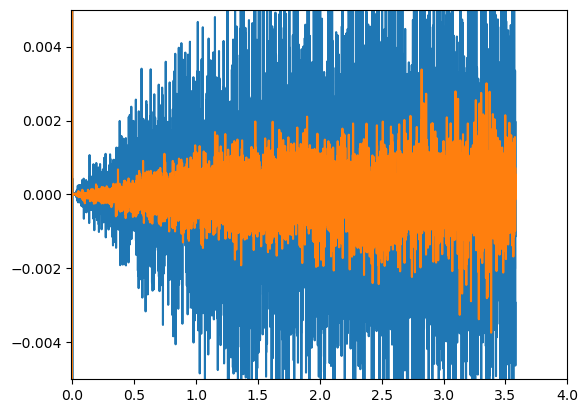

In [12]:
# check this
%matplotlib inline
print(len(allNaI_raw))
plt.plot(xs, sum_ch_raw[1]/np.sum(all_sequences))
plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.005, 0.005)
plt.xlim(-0.01, 4.0)

In [13]:
fpl = 23.31
daq_delay = 0

m_n = 1.6749286*10**(-27)
# L = 0
J_to_eV = 6.24151*10**18
eV_to_J = 1.602176565*10**-19

def tof_to_eV(xtof, FPlength, t_off):
    m_n = 1.6749286*10**(-27)
    delay = t_off
    x_eV_out = 0.5*m_n*((FPlength/((xtof+delay)/1000)))**2*J_to_eV  ## tof in ms
    return x_eV_out
def eV_to_tof(xeV, FPlength, t_off):
    m_n = 1.6749286*10**(-27)
    delay = t_off
    x_tof_out = delay + 1000*FPlength*np.sqrt(m_n/(2*xeV*eV_to_J))  ## tof in ms
    return x_tof_out

In [14]:
print(tof_to_eV(0.780, fpl, daq_delay))
print(eV_to_tof(4.79, fpl, daq_delay))

4.668220001093984
0.7700208426295269


In [15]:
import sys

def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
    print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))


                    all_raw_og: 619.1 MiB
                       all_raw: 566.0 MiB
                  all_raw_D_og: 322.0 MiB
                  all_raw_U_og: 322.0 MiB
                    sum_ch_raw:  1.7 MiB
                            xs: 70.4 KiB
            asym_raw_chdataset: 70.4 KiB
                         chraw: 70.4 KiB
                    allNaI_raw: 70.4 KiB
                       all_amp: 67.8 KiB


In [16]:
del all_raw_D_og ## might help with memory issues
del all_raw_U_og
del all_raw_og
# del run_rawasym_D
# del run_rawasym_U
# del run_ampasym_D
# del run_ampasym_U
# del flatrunslist_D
# del flatrunslist_U
# del asym_raw_chdataset

In [17]:
for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
    print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))

                       all_raw: 566.0 MiB
                    sum_ch_raw:  1.7 MiB
                            xs: 70.4 KiB
            asym_raw_chdataset: 70.4 KiB
                         chraw: 70.4 KiB
                    allNaI_raw: 70.4 KiB
                       all_amp: 67.8 KiB
                  all_integral: 67.8 KiB
                           _i6:  5.3 KiB
                           _i9:  3.7 KiB


In [18]:

def loadrun_pulseadd(run, processedpath): ## not sure if this is the fastest way, or passing a list of runs...
    runname = processedpath+run
#     print(runname)
    with h5py.File(runname, 'r') as f:
        channels = list(f.keys())
        numchannels = len(channels)-1
        arrsizer = f[channels[-1]] ## gets the xs array
        arrsizer = np.asarray(arrsizer)
        numpoints = len(arrsizer)
#             num_seq = f.attrs.get('sequences')
#             numsequences.append(num_seq)
        rundat = np.zeros((numchannels,numpoints),dtype = np.float64)
#             print(str(np.char.zfill(str(chan_enab[i]),2)))
#             dataset = f['ch '+str(np.char.zfill(str(chan_enab[i]), 2))]
        for i in range(0,numchannels):
            dataset = f[channels[i]+'/added_pulses/'+channels[i]][:]  ##change this to match channels[i]
            chdata = np.array(dataset)
#                     print(chdata)
#                     print(np.size(chdata))
#                     print(len(chdata[0]))
#                     print(rundat)
            rundat[i] = rundat[i]+chdata
        f.close()
    return rundat

start=time.time()
# all_D = [] 
# all_D = np.zeros((numruns_tot_D, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
# all_U = np.zeros((numruns_tot_U, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
all_D = [] ## in this case cannot be np array because it is not same size arrays ## will be run, channel, numpoints
all_U = []

for f in range(0,len(folderslist)):
    fpath = root+processedfolder+folderslist[f]
    print(fpath)
    for r in range(0, len(runslist_D[f])):
        # print(runslist_D[f][r])
        all_D.append(loadrun_pulseadd(runslist_D[f][r][:5]+'_pulseadd_D.h5', fpath+'/pulseadd_D/'))  ## added pulseadd str to this
        all_U.append(loadrun_pulseadd(runslist_U[f][r][:5]+'_pulseadd_U.h5', fpath+'/pulseadd_U/'))
#         print(all_D[r])
    print(fpath+' done')

all_D = np.asarray(all_D)
all_U = np.asarray(all_U)
    
print('original downstream dets shape', all_D.shape)
all_D = np.asarray(all_D.transpose(1,0,2))  ## re-shape into ch, run, points
all_U = np.asarray(all_U.transpose(1,0,2))
print('new downstream dets shape', all_D.shape)
    
end=time.time()
print('loaded pulseadd files time: ', end-start)

F:\LANL/processed_data/runs12686-13279/
F:\LANL/processed_data/runs12686-13279/ done
F:\LANL/processed_data/runs13280-13563/
F:\LANL/processed_data/runs13280-13563/ done
F:\LANL/processed_data/runs13564-13604/
F:\LANL/processed_data/runs13564-13604/ done
original downstream dets shape (361, 13, 8992)
new downstream dets shape (13, 361, 8992)
loaded pulseadd files time:  7.942317485809326


In [19]:
np.set_printoptions(suppress=True, precision=6)

In [20]:
## make an array of random seq asym values for autocorr. Better than repeating same run asym value 13 times.

window = 0.018/13
seq_rands = []
for ch in range(0, len(all_amp)):
    run_rands = []
    for r in range(0, len(all_amp[ch])):
        run_rand = []
        target = all_amp[ch][r]
        seqsize = all_sequences[r]
        # print(target)
        random_floats_arr = np.random.default_rng().uniform(low=(target/13-window), high=((target/13+window)), size=seqsize)
        run_rands.append(random_floats_arr)
        # print(np.sum(random_floats_arr), all_amp[ch][r])
    flat_rands = [item for sublist in run_rands for item in sublist]
    flat_rands = np.array(flat_rands)
    seq_rands.append(flat_rands)
    # print(flat_rands.shape)

seq_rands = np.array(seq_rands)
print(seq_rands.shape)


(24, 4686)


(4686,)
Detector: 5
R (runs): 361
N_seq (per detector): 4686
rho1: 0.925615678641571
noise_level (2/sqrt(N)): 0.029216544754801246
cutoff lag: 20
tau_sum (truncated): 13.907619103064064
N_eff (truncated): 336.9376142151895
mu (weighted per-run mean): -0.019804534978719465
sigma_w (weighted std): 1.0199290418658404
SE_seq: 0.01489940124919744
SE_run: 0.05368047588767581
SE_neff: 0.05556421844635089


<>:91: SyntaxWarning: invalid escape sequence '\h'
<>:91: SyntaxWarning: invalid escape sequence '\h'
C:\Users\gabeo\AppData\Local\Temp\ipykernel_38836\2813498917.py:91: SyntaxWarning: invalid escape sequence '\h'
  plt.title(f'Autocorrelation $\hat\\rho_k$, det. {det}, runs organized with $N_{{seq}}$')


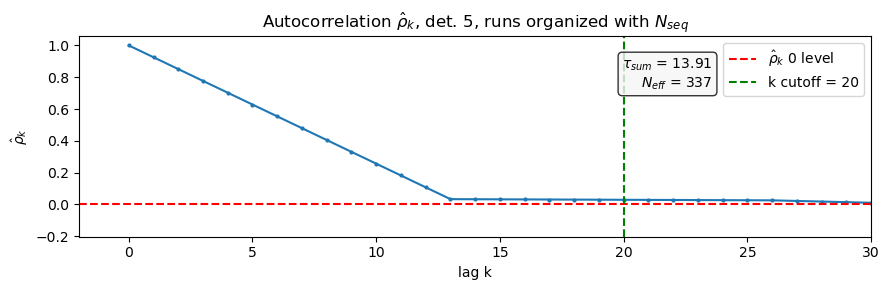

In [21]:
%matplotlib inline
# -------------- load data --------------
# data = np.load("F:/LANL/asym_all_detectors.npz")
# Nr = data["arr1"].astype(int)   # shape (R,)
# A = data["arr2"].astype(float)  # shape (D, R)

Nr = np.asarray(all_sequences, dtype =np.int32)   # shape (R,)
A = all_amp  # shape (D, R)
# print(type(Nr[0]), type(A[0][0]))
D, R = A.shape
N_seq = int(Nr.sum())

# choose detector (zero-based index)
det = 5

# -------------- flatten per-sequence series --------------
per_run = A[det]                # length R
# seq_series = np.repeat(per_run, Nr)   # length N_seq
seq_series = seq_rands[det]   # length N_seq
print(seq_series.shape)
# run_series = all_amp[det]

# -------------- autocorr estimator (normalized) --------------
def autocorr_rho_full(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_lag is None or max_lag > n-1:
        max_lag = n-1
    xm = x - x.mean()
    denom = np.sum(xm * xm)
    corr_full = np.correlate(xm, xm, mode='full')
    corr = corr_full[n-1:n+max_lag+1]    # lags 0..max_lag
    rho = corr / denom
    return rho  # rho[0] = 1

max_lag = min(2000, N_seq-1)
rho = autocorr_rho_full(seq_series, max_lag=max_lag)
# rho = autocorr_rho_full(run_series, max_lag=max_lag)

# -------------- cutoff rule (first negative or below noise) --------------
noise_level = 2.0 / math.sqrt(N_seq)
cutoff = max_lag
for k in range(1, len(rho)):
    if rho[k] < 0 or rho[k] < noise_level:
        cutoff = k-1
        break

# -------------- tau, Neff --------------
if cutoff >= 1:
    tau_sum = 1.0 + 2.0 * np.sum(rho[1:cutoff+1])
else:
    tau_sum = 1.0
Neff_sum = N_seq / tau_sum if tau_sum > 0 else 1.0
# Neff_sum = R / tau_sum if tau_sum > 0 else 1.0


# -------------- weighted std and SEs --------------
# weighted mean per-run for this detector:
mu = np.average(per_run, weights=Nr)
var_w = np.sum(Nr * (per_run - mu)**2) / N_seq
sigma_w = math.sqrt(var_w)

SE_seq = sigma_w / math.sqrt(N_seq)
SE_run = sigma_w / math.sqrt(R)
SE_neff = sigma_w / math.sqrt(Neff_sum)

# -------------- print results --------------
print("Detector:", det)
print("R (runs):", R)
print("N_seq (per detector):", N_seq)
print("rho1:", rho[1])
print("noise_level (2/sqrt(N)):", noise_level)
print("cutoff lag:", cutoff)
print("tau_sum (truncated):", tau_sum)
print("N_eff (truncated):", Neff_sum)
print("mu (weighted per-run mean):", mu)
print("sigma_w (weighted std):", sigma_w)
print("SE_seq:", SE_seq)
print("SE_run:", SE_run)
print("SE_neff:", SE_neff)

# -------------- plot rho_k --------------
lags = np.arange(len(rho))
plt.figure(figsize=(9,3))
plt.plot(lags[:200], rho[:200], marker='.', markersize=4, linestyle='-')
# plt.axhline(noise_level, color='red', linestyle='--', label=f'noise level = {noise_level:.4f}')
plt.axhline(0, color='red', linestyle='--', label=r'$\hat\rho_k$ 0 level')
plt.axvline(cutoff, color='green', linestyle='--', label=f'k cutoff = {cutoff}')
plt.xlabel('lag k')
plt.ylabel(r'$\hat\rho_k$')
plt.title(f'Autocorrelation $\hat\\rho_k$, det. {det}, runs organized with $N_{{seq}}$')
plt.xlim(-2, 30)
plt.legend()

# Create a text box next to the legend
textstr = f'$\\tau_{{sum}}$ = {tau_sum:.2f}\n$N_{{eff}}$ = {Neff_sum:.0f}'

# Get the legend box position
leg = plt.gca().get_legend()
if leg:
    bbox = leg.get_frame().get_bbox()
    x0 = bbox.x1 - 0.05  # small offset to the right of legend
    y0 = bbox.y0 + 0.05
else:
    x0, y0 = 0.8, 0.8  # fallback position

# Place the annotation box
plt.gca().text(0.8, 0.9, textstr, transform=plt.gca().transAxes,
               fontsize=10, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='whitesmoke', alpha=0.8))

plt.tight_layout()
plt.show()


In [22]:
def w_asym(asym_array, sequences, N_input):
    # Check if multiple detectors or not
    single_channel = False
    if asym_array.ndim == 1:
        single_channel = True
        asym_array = asym_array[None, :]  # shape (1, R)
    ## definitions for clarity
    D, R = asym_array.shape  # number of detectors, runs
    # N_r = sequences              # sequences per run
    N_s = np.sum(sequences)          # total sequences per detector
    N_tot = D*N_input  ## this is N_eff, but generalized to be N_r, N_seq, or N_eff from autocorr.,etc. D accounts for # detectors, 1 (D=1) or multiple

    # weighted mean per det
    weighted_sum = np.sum(asym_array * sequences[None, :], axis=1)  # shape (D,)
    mu_det = weighted_sum / N_s
    # SE per detector
    resid = asym_array - mu_det[:, None]
    S_d = np.sum(sequences[None, :] * resid**2, axis=1) #weighted sum of residuals
    sigma2_d = S_d / N_s
    se_det = np.sqrt(sigma2_d / N_input)  ##equivalent to N_tot=D*N_input for 1 detector D=1 
    if single_channel==True:  ## end here for 1 channel
        return mu_det[0], se_det[0]
        
    # if D>1, find the final weighted asym +/- error
    mu_total = np.sum(weighted_sum) / (D*N_s)
    resid_total = asym_array - mu_total
    S_total = np.sum(sequences[None, :] * resid_total**2)
    sigma2_total = S_total / (D*N_s)
    se_total = np.sqrt(sigma2_total / N_tot)
    if single_channel==False:
        return mu_total, se_total
        # return mu_det, se_det, mu_total, se_total  #if channels and totals are wanted. I find it a little confusing this way. 

In [23]:
all_amp_norm = all_amp/all_sequences ## only use this for histograms, not weighted avg
all_NaI_amp = all_amp_norm.flatten()
all_int_norm = all_integral/all_sequences ## only use this for histograms, not weighted avg
all_NaI_int = all_int_norm.flatten()

In [24]:
N_seq = np.sum(all_sequences)
N_r = all_sequences.shape[0]
N_eff = N_seq / tau_sum if tau_sum > 0 else 1.0
print(N_seq, N_r, N_eff)

mean_det_amp_seq, stderr_det_amp_seq = [], []  ## now these should be corectly weighted!
mean_det_amp_r, stderr_det_amp_r = [], []  ## now these should be corectly weighted!
mean_det_amp_eff, stderr_det_amp_eff = [], []  ## now these should be corectly weighted!
for ch in range(0, all_amp_norm.shape[0]):  # each detector
    mu_ch, se_ch = w_asym(all_amp_norm[ch], all_sequences, N_seq)
    mean_det_amp_seq.append(mu_ch)
    stderr_det_amp_seq.append(se_ch)
    #### use N_r
    mu_ch, se_ch = w_asym(all_amp_norm[ch], all_sequences, N_r)
    mean_det_amp_r.append(mu_ch)
    stderr_det_amp_r.append(se_ch)
    #### use N_eff
    mu_ch, se_ch = w_asym(all_amp_norm[ch], all_sequences, N_eff)
    mean_det_amp_eff.append(mu_ch)
    stderr_det_amp_eff.append(se_ch)

mean_det_amp_seq, stderr_det_amp_seq = np.array(mean_det_amp_seq), np.array(stderr_det_amp_seq)
mean_det_amp_r, stderr_det_amp_r = np.array(mean_det_amp_r), np.array(stderr_det_amp_r)
mean_det_amp_eff, stderr_det_amp_eff = np.array(mean_det_amp_eff), np.array(stderr_det_amp_eff)

mean_all_amp_seq, se_all_amp_seq = w_asym(all_amp_norm, all_sequences, N_seq)
mean_all_amp_r, se_all_amp_r = w_asym(all_amp_norm, all_sequences, N_r)
mean_all_amp_eff, se_all_amp_eff = w_asym(all_amp_norm, all_sequences, N_eff)

4686 361 336.9376142151895


In [25]:
# re-do for integral method

mean_det_int_r, stderr_det_int_r = [], []  ## now these should be corectly weighted!
for ch in range(0, all_int_norm.shape[0]):  # each detector
    #### use N_r
    mu_ch, se_ch = w_asym(all_int_norm[ch], all_sequences, N_r)
    mean_det_int_r.append(mu_ch)
    stderr_det_int_r.append(se_ch)

mean_det_int_r, stderr_det_int_r = np.array(mean_det_int_r), np.array(stderr_det_int_r)
mean_all_int_r, se_all_int_r = w_asym(all_int_norm, all_sequences, N_r)

In [26]:
# # mean_corner, se_corner = w_asym(all_amp[corner_idx], all_sequences)
# # mean_noncorner, se_noncorner = w_asym(all_amp[noncorner_idx], all_sequences)
# print(mean_all, se_all)
# print(w_mean_all_amp, stderr_all_amp)  #std err all amp not the same i guess

# ch = 4
# w_mean_det_amp2, stderr_det_amp2 = w_asym(all_amp[ch], all_sequences, N_seq)
# print()
# print(w_mean_det_amp[ch], stderr_det_amp[ch])
# print(w_mean_det_amp2, stderr_det_amp2)
# print(w_mean_det_amp_new[ch], stderr_det_amp_new[ch])

In [27]:
print('Using N_seq')
print('individual detectors average: ', np.round(mean_det_amp_seq,8) )
print('individual detectors SE: ', np.round(stderr_det_amp_seq,8) )
print()
print('24 det. ensemble average: ', np.round(mean_all_amp_seq,8) )
print('24 det. ensemble SE: ', np.round(se_all_amp_seq,8) )

Using N_seq
individual detectors average:  [-0.011055 -0.000119 -0.003115 -0.005776 -0.004696 -0.001573  0.001016
 -0.002223  0.003319  0.000093  0.000632  0.000481  0.000881  0.002486
  0.00088   0.001404 -0.001763 -0.001455 -0.00619  -0.002587  0.000798
  0.008311  0.00335   0.004365]
individual detectors SE:  [0.002729 0.0007   0.000736 0.001287 0.000794 0.001147 0.002226 0.00091
 0.000764 0.001527 0.00088  0.000772 0.00101  0.000556 0.000568 0.001045
 0.00068  0.000576 0.001108 0.000684 0.000691 0.001303 0.000718 0.000575]

24 det. ensemble average:  -0.00052233
24 det. ensemble SE:  0.00023002


##### some detector combination definitions

In [28]:
# corner v noncorner
corners = [0,3,6,9,12,15,18,21]
corner_amp_norm = np.asarray(all_amp_norm[corners]).flatten()
noncorners = [1,2,4,5,7,8,10,11,13,14,16,17,19,20,22,23]
noncorner_amp_norm = np.asarray(all_amp_norm[noncorners]).flatten()
print(all_amp_norm[noncorners].shape, (noncorner_amp_norm.shape))
# noncorner_amp_norm = noncorner_amp_norm[0].flatten()

# left v right
left = [2,3,4,5,6,7,20,21,22,23,12,13] ## BEAM left and right
# left2 = [3,4,5,6,21,22,23,12] ## These are exclusively the 4 on the side
left_amp_norm = np.asarray(all_amp_norm[left]).flatten()
print(all_amp_norm[left].shape, (left_amp_norm.shape))
right = [0,1,8,9,10,11,14,15,16,17,18,19] ## BEAM right
# right2 = [0,9,10,11,15,16,17,18] ## These are exclusively the 4 on the side
right_amp_norm = np.asarray(all_amp_norm[right]).flatten()
print(all_amp_norm[right].shape, (right_amp_norm.shape))

# top v bot
top = [0,1,2,3,12,13,14,15] ## these are exclusively the top
top_amp_norm = np.asarray(all_amp_norm[top]).flatten()
print(all_amp_norm[top].shape, (top_amp_norm.shape))
bottom = [6,7,8,9,18,19,20,21] ## exclusively the bottom
bottom_amp_norm = np.asarray(all_amp_norm[bottom]).flatten()
print(all_amp_norm[bottom].shape, (bottom_amp_norm.shape))

(16, 361) (5776,)
(12, 361) (4332,)
(12, 361) (4332,)
(8, 361) (2888,)
(8, 361) (2888,)


In [29]:
plt.rcParams.update({
    'axes.titlesize': 'xx-large',
    'axes.labelsize': 'x-large',
    'xtick.labelsize': 'x-large',
    'ytick.labelsize': 'x-large',
    'xtick.minor.visible': 'True',
    'ytick.minor.visible': 'True',
    'axes.grid': 'True',
    'axes.grid.which': 'both',
    'grid.alpha': '0.70',
    'grid.linestyle': ':',
    'legend.fontsize': 'large',
    'figure.figsize': '10.0, 7.0',
    'backend': 'Qt5agg',
    'interactive': 'True',
    'figure.autolayout': 'True',
})
# %matplotlib qt
print('updated rcparam')

updated rcparam


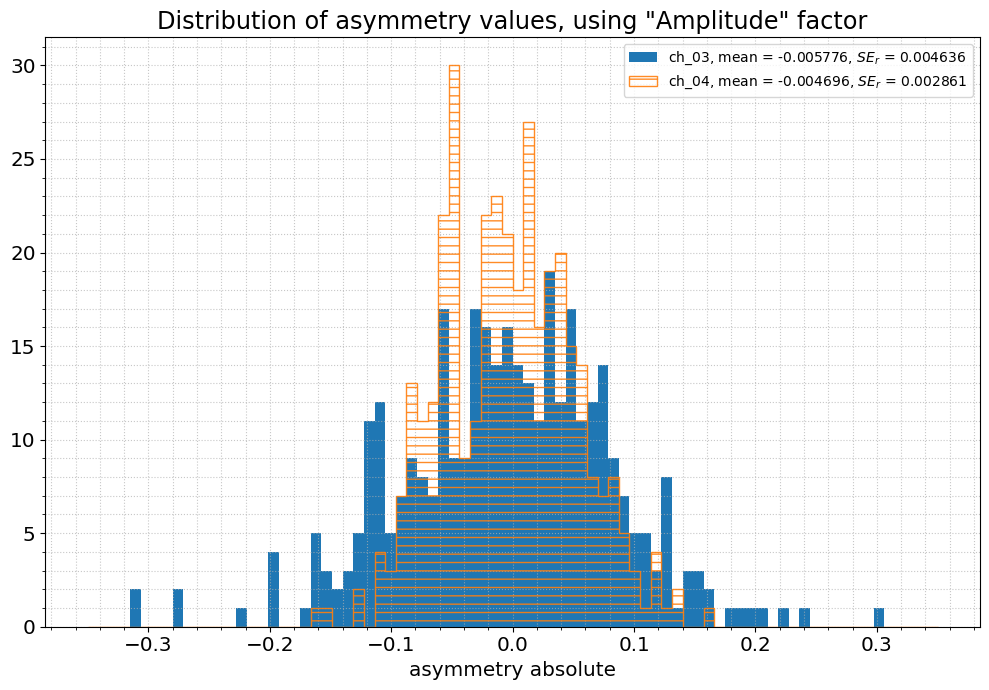

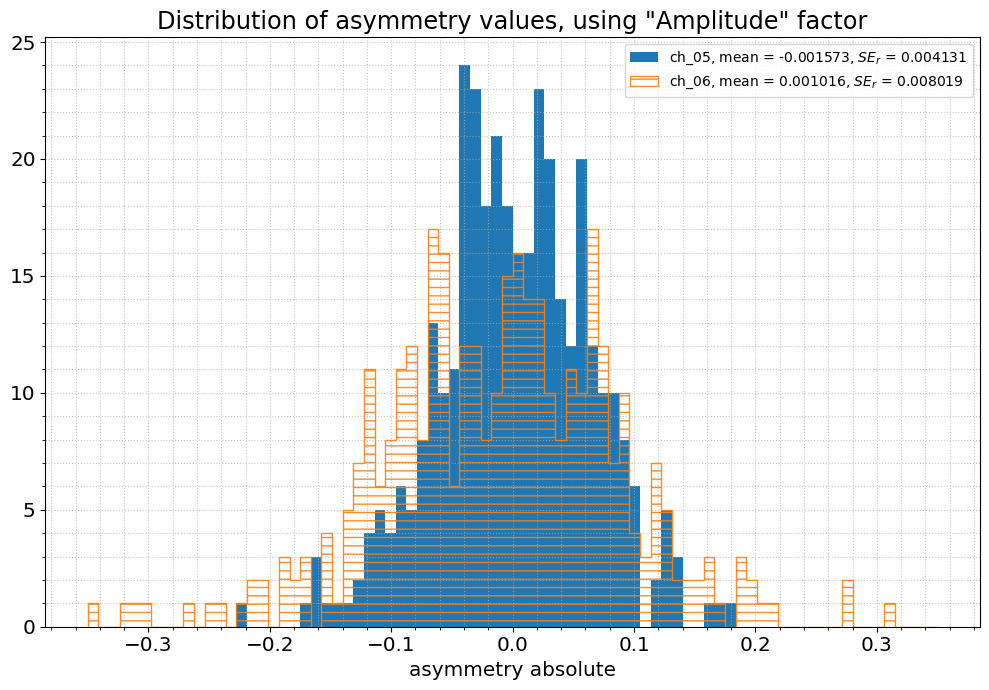

In [30]:
%matplotlib inline
# all_amp_norm = all_amp/(all_sequences) # just for hists, not for weighted avg
ch = 3
bval = 80
r = [-0.35,0.35]
rnd = 6

plt.figure()
plt.title(rf'Distribution of asymmetry values, using "Amplitude" factor', fontsize = 'xx-large')
wmean  = np.round(mean_det_amp_r[ch],rnd)
wstd   = np.round(stderr_det_amp_r[ch],rnd)
wmean2 = np.round((mean_det_amp_r[ch+1]),rnd)
wstd2  = np.round((stderr_det_amp_r[ch+1]),rnd)
plt.hist(all_amp_norm[ch], bins =bval, range = r,  label = channels_all[ch]+f', mean = {wmean}, $SE_{{r}}$ = {wstd}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(all_amp_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {wmean2}, $SE_{{r}}$ = {wstd2}')  ## all runs, ch, parameters array, sigma value
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

ch = ch+2
plt.figure()
plt.title(rf'Distribution of asymmetry values, using "Amplitude" factor', fontsize = 'xx-large')
wmean  = np.round(mean_det_amp_r[ch],rnd)
wstd   = np.round(stderr_det_amp_r[ch],rnd)
wmean2 = np.round((mean_det_amp_r[ch+1]),rnd)
wstd2  = np.round((stderr_det_amp_r[ch+1]),rnd)
plt.hist(all_amp_norm[ch], bins =bval, range = r,  label = channels_all[ch]+f', mean = {wmean}, $SE_{{r}}$ = {wstd}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(all_amp_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {wmean2}, $SE_{{r}}$ = {wstd2}')  ## all runs, ch, parameters array, sigma value
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

In [31]:
print(numruns_tot_D)

361


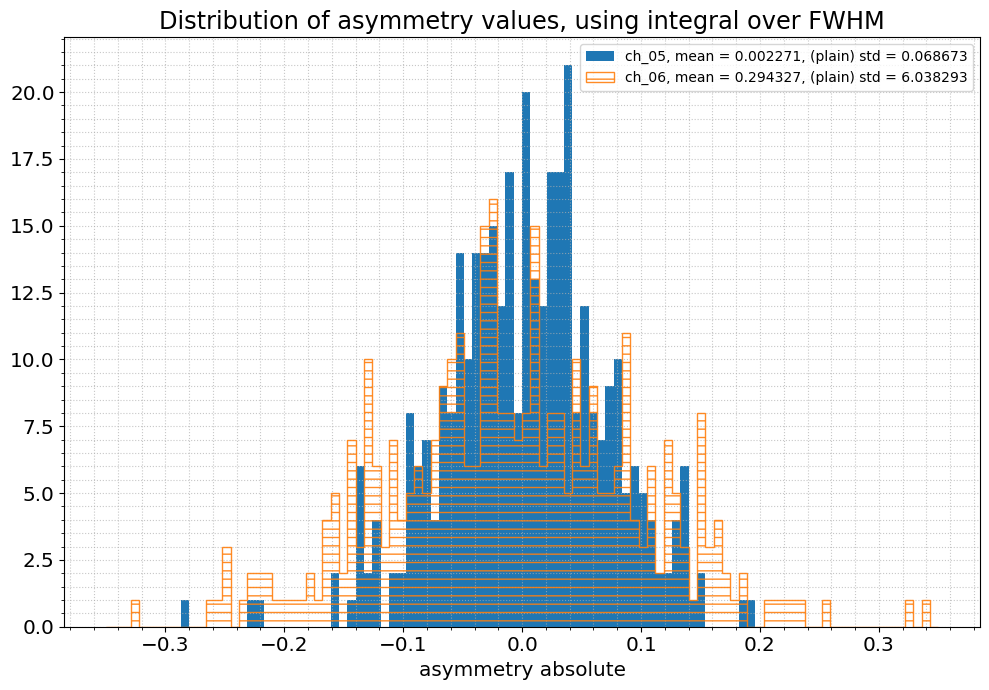

In [32]:
# ch = 8
bval = 100
r = [-0.35,0.35]
rnd = 6
# factor = all_sequences[ch]
plt.title(rf'Distribution of asymmetry values, using integral over FWHM', fontsize = 'xx-large')
mean = np.round(np.mean(all_int_norm[ch]),rnd)
std = np.round(np.std(all_int_norm[ch]),rnd)
mean2 = np.round(np.mean(all_int_norm[ch+1]),rnd)
std2 = np.round(np.std(all_int_norm[ch+1]),rnd)

wmean  = np.round(mean_det_int_r[ch],rnd)
wstd   = np.round(stderr_det_int_r[ch],rnd)
wmean2 = np.round((mean_det_int_r[ch+1]),rnd)
wstd2  = np.round((stderr_det_int_r[ch+1]),rnd)
plt.hist(all_int_norm[ch], bins =bval, range = r,  label = channels_all[ch]+f', mean = {mean}, (plain) std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(all_int_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {mean2}, (plain) std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

In [33]:
# amp_integral_means = [[],[]]
# amp_integral_stds = [[],[]]

# for ch in range(0, len(all_amp)):
#     mamp = np.mean(all_amp_norm[ch])
#     samp = np.std(all_amp_norm[ch])
#     mint = np.mean(all_integral_norm[ch])
#     sint = np.std(all_integral_norm[ch])
#     amp_integral_means[0].append(mamp)
#     amp_integral_stds[0].append(samp)
#     amp_integral_means[1].append(mint)
#     amp_integral_stds[1].append(sint)

# amp_integral_means = np.asarray(amp_integral_means)
# amp_integral_stds = np.asarray(amp_integral_stds)
# mean_diffs = amp_integral_means[0]-amp_integral_means[1]
# # print(amp_integral_means[0])

# # print(amp_integral_means)

# df1 = pd.DataFrame(amp_integral_means)
# print(df1)
# print(mean_diffs)

In [34]:
# ## all 24, amplitude / integral
# ## this is old

# %matplotlib inline
# r = [-0.04,0.04]
# b = 100

# all_NaI_amp = all_amp_norm.flatten()
# # all_NaI_amp = np.sum(all_amp_norm, axis = 0)
# # print(len(testsum))
# plt.title(rf'All 24 NaI detectors, different methods', fontsize = 'xx-large')
# mean = np.round(np.mean(all_NaI_amp),6)
# std = np.round(np.std(all_NaI_amp)/(np.sqrt(numruns_tot_D*24)),6)

# n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'Amplitude method\nmean = {mean}, (std/ $\\sqrt{{N_R*N_D}}$) = {std}')
# print(mean)
# print(np.mean(sum_ch_amp))

# all_NaI_int = all_int_norm.flatten()
# # all_NaI_int = np.sum(all_int_norm, axis = 0)
# # print(len(testsum))
# # plt.title(rf'maybe all 24 detectors using integral over FWHM', fontsize = 'xx-large')
# mean2 = np.round(np.mean(all_NaI_int),6)
# std2 = np.round(np.std(all_NaI_int)/(np.sqrt(numruns_tot_D*24)),6)

# n_int, bins_int, patches_int = plt.hist(all_NaI_int,bins=b,range=r, label = f'Integral method\nmean = {mean2}, std = {std2}', alpha =0.9, hatch='--',histtype='step')

# def gauss(x,amp,mu,sigma): # deinition of function
#     return amp*np.exp(-(x-mu)**2/2*sigma**2)

# y_amp = n_amp
# y_int = n_int
# x = np.linspace(r[0],r[1], b)

# popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[100,0,2]) # popt= optimize parameter
# plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mean={np.round(popt_amp[0],5)}, mu={np.round(popt_amp[1],5)}')
# popt_int,pcov_int=curve_fit(gauss,x,y_int,p0=[100,0,2]) # popt= optimize parameter
# plt.plot(x,gauss(x,*popt_int),color='orange',lw=2.0,ls = '--',label=f'Integral Gaussian fit mean={np.round(popt_int[0],5)}, mu={np.round(popt_int[1],5)}')
# # print('amp',popt[0]) # amp
# # print('meam',popt[1])# mean mu
# # print('sigma',popt[2]) # sigma


# plt.xlabel('asymmetry absolute')
# plt.legend()
# plt.show()
# print(mean2)
# # print(np.mean(sum_ch_integral))


In [35]:
## general function for reduced chi square for a given fit function. sigma is important to estimate.

def chi_square_dof(fit_func, xdata, ydata, popt, sigma=None):
    """
    Calculate chi-square and degrees of freedom for a fit.

    Parameters:
        fit_func : callable
            The model function, f(x, ...).
        xdata : array_like
            The independent variable where the data is measured.
        ydata : array_like
            The dependent data — measured values.
        popt : array_like
            Optimal values for the parameters from curve_fit.
        sigma : array_like or None
            Standard deviation errors of ydata. If None, equal weights assumed.

    Returns:
        chi2 : float
            Chi-square statistic.
        dof : int
            Degrees of freedom.
        reduced_chi2 : float
            Reduced chi-square (chi2 / dof)
    """
    yfit = fit_func(xdata, *popt)
    residuals = ydata - yfit
    if sigma is None:
        chi2 = np.sum(residuals**2)
    else:
        chi2 = np.sum((residuals / sigma)**2)
    dof = len(ydata) - len(popt)
    reduced_chi2 = chi2 / (dof)
    return residuals, chi2, dof, reduced_chi2

def gauss(x,amp,mu,sigma): # deinition of function
    return amp*np.exp(-(x-mu)**2/(2*sigma**2))

<>:24: SyntaxWarning: invalid escape sequence '\c'
<>:24: SyntaxWarning: invalid escape sequence '\c'
C:\Users\gabeo\AppData\Local\Temp\ipykernel_38836\3909035308.py:24: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(x,gauss(x,*popt_amp),color='red',lw=1.5,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}, $\chi$/dof={np.round(chi2_amp[-1],4)}')


chi square/dof for amp:  1.0309278350515463
amp 86.53042713994495
sigma 24897797.313278772


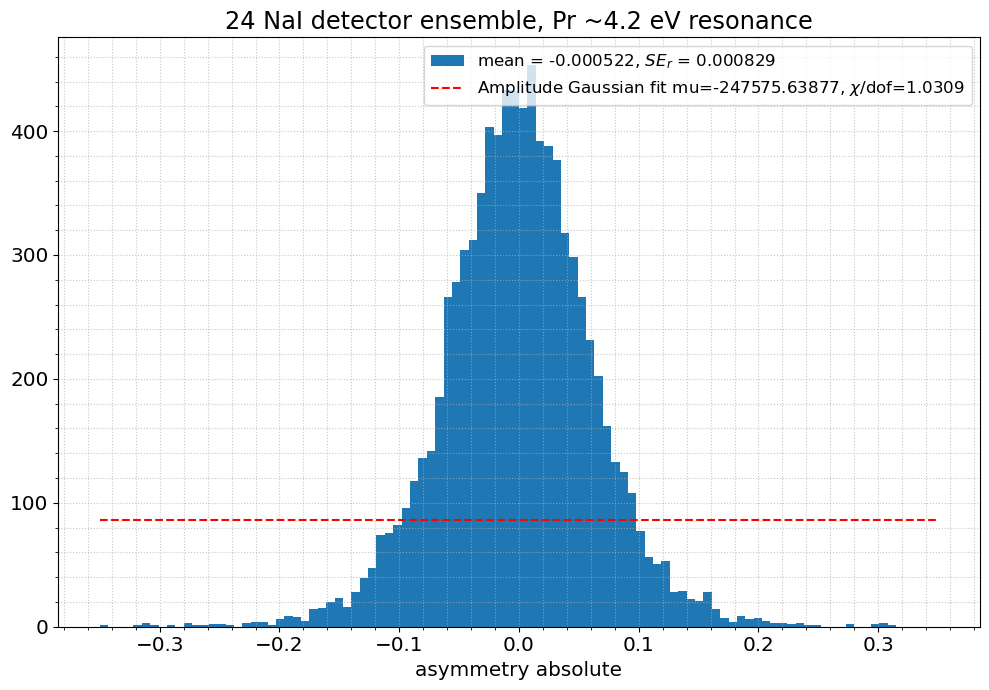

In [36]:
## all 24, amplitude different Ns --- N_seq
## redo with chisquare for gaussian fit

%matplotlib inline
r = [-0.35,0.35]
b = 100

plt.title(rf'24 NaI detector ensemble, Pr ~4.2 eV resonance', fontsize = 'xx-large')
mean = np.round(mean_all_amp_r,6)
std = np.round(se_all_amp_r,6)
n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'mean = {mean}, $SE_{{r}}$ = {std}')

y_amp = n_amp
x = np.linspace(r[0],r[1], b)

popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[1200,0.07,150]) # popt= optimize parameter
# sig = 1/np.sqrt(y_amp)
sig = gauss(x, *popt_amp) - n_amp
# sig[sig == 0] = 1
# sig = None

chi2_amp = chi_square_dof(gauss,x,y_amp, popt_amp, sig)
print('chi square/dof for amp: ', chi2_amp[-1])
plt.plot(x,gauss(x,*popt_amp),color='red',lw=1.5,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}, $\chi$/dof={np.round(chi2_amp[-1],4)}')
# plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}')

print('amp',popt_amp[0]) # amp
# print('mean',popt_amp[1], '+/-', pcov_amp.diag[1])# mean mu
print('sigma',popt_amp[2]) # sigma
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\c'
<>:29: SyntaxWarning: invalid escape sequence '\c'
C:\Users\gabeo\AppData\Local\Temp\ipykernel_38836\3395421123.py:29: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(x,gauss(x,*popt_amp),color='red',lw=1.5,ls = '--',label=f'Gaussian fit mu={np.round(popt_amp[1],5)}, $\chi$/dof={np.round(chi2_amp[-1],4)}')
C:\Users\gabeo\AppData\Local\Temp\ipykernel_38836\3395421123.py:21: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[700,0,150]) # popt= optimize parameter


chi square/dof for amp:  1.0309278350515463
amp 86.53000033874306
mean -38.71320468134661
sigma 80313596.68007763


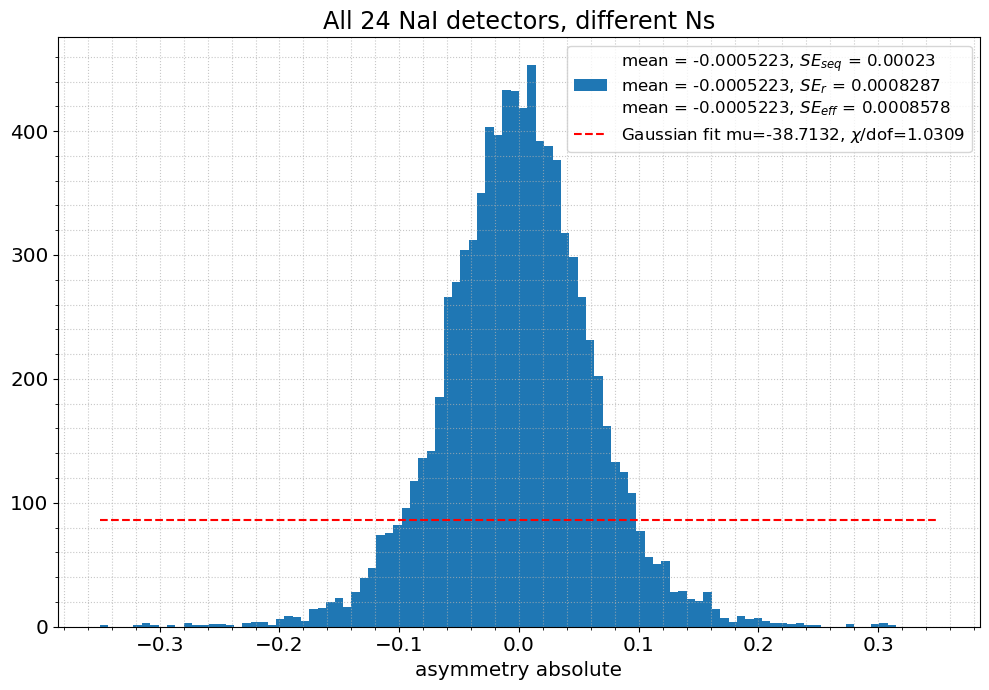

In [37]:
## all 24, amplitude different Ns --- all Ns
## redo with chisquare for gaussian fit

%matplotlib inline
r = [-0.35,0.35]
b = 100
rnd = 7

plt.title(rf'All 24 NaI detectors, different Ns', fontsize = 'xx-large')
mean = np.round(mean_all_amp_seq,rnd)
std = np.round(se_all_amp_seq,rnd)
mean2 = np.round(mean_all_amp_r,rnd)
std2 = np.round(se_all_amp_r,rnd)
mean3 = np.round(mean_all_amp_eff,rnd)
std3 = np.round(se_all_amp_eff,rnd)
n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'mean = {mean}, $SE_{{seq}}$ = {std}\nmean = {mean2}, $SE_{{r}}$ = {std2} \nmean = {mean3}, $SE_{{eff}}$ = {std3}')

y_amp = n_amp
x = np.linspace(r[0],r[1], b)

popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[700,0,150]) # popt= optimize parameter
# sig = 1/np.sqrt(y_amp)
sig = gauss(x, *popt_amp) - n_amp
# sig[sig == 0] = 1
# sig = None

chi2_amp = chi_square_dof(gauss,x,y_amp, popt_amp, sig)
print('chi square/dof for amp: ', chi2_amp[-1])
plt.plot(x,gauss(x,*popt_amp),color='red',lw=1.5,ls = '--',label=f'Gaussian fit mu={np.round(popt_amp[1],5)}, $\chi$/dof={np.round(chi2_amp[-1],4)}')
# plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}')

print('amp',popt_amp[0]) # amp
print('mean',popt_amp[1])# mean mu
print('sigma',popt_amp[2]) # sigma
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:54: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\p'
C:\Users\gabeo\AppData\Local\Temp\ipykernel_38836\4136350646.py:41: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amp. method $\mu$ = {popt_amp[1]:.2e} $\pm$ {amp_err[1]:.2e}')
C:\Users\gabeo\AppData\Local\Temp\ipykernel_38836\4136350646.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amp. method $\mu$ = {popt_amp[1]:.2e} $\pm$ {amp_err[1]:.2e}')
C:\Users\gabeo\AppData\Local\Temp\ipykernel_38836\4136350646.py:54: SyntaxWarning: invalid escape sequ

-0.0005223
amp method param.:  [426.588831  -0.000101   0.05561 ]
chi square/dof for amp:  1.0623048201864063
int method param.:  [390.107364  -0.000094   0.060118]
chi square/dof for int:  1.9613027192789438


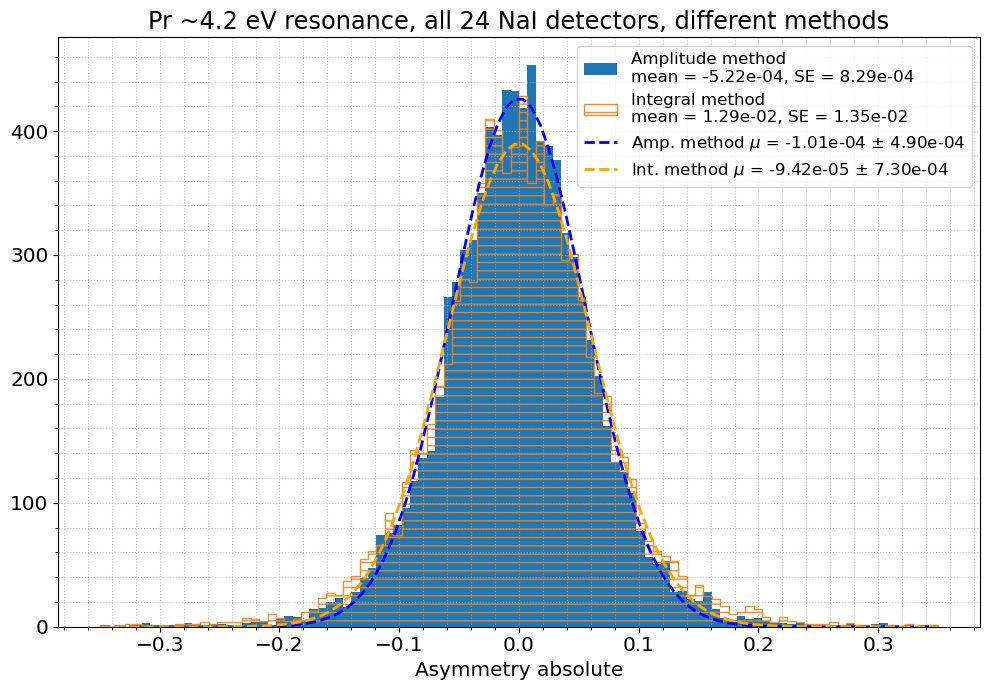

0.0128573


In [38]:
## all 24, amplitude / integral
## redo with chisquare for gaussian fit

%matplotlib inline
r = [-0.35,0.35]
b = 100
rd = 7

plt.title(rf'Pr ~4.2 eV resonance, all 24 NaI detectors, different methods', fontsize = 'xx-large')
mean = np.round(mean_all_amp_r,rd)
std = np.round(se_all_amp_r,rd)
n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'Amplitude method\nmean = {mean:.2e}, SE = {std:.2e}')
print(mean)

# plt.title(rf'maybe all 24 detectors using int over FWHM', fontsize = 'xx-large')
mean2 = np.round(mean_all_int_r,rd)
std2 = np.round(se_all_int_r,rd)

n_int, bins_int, patches_int = plt.hist(all_NaI_int,bins=b,range=r, label = f'Integral method\nmean = {mean2:.2e}, SE = {std2:.2e}', alpha =0.9, hatch='--',histtype='step')

y_amp = n_amp
y_int = n_int
x = np.linspace(r[0],r[1], b)

popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[1200,-0.01,1], bounds = ([200,r[0],0], [2000,r[1],np.inf])) # popt= optimize parameter
print('amp method param.: ', popt_amp)
amp_err = np.sqrt(np.diag(pcov_amp))
s_test = np.ones(len(y_amp))*9.62
# s_test = np.ones(len(y_amp))*np.mean(np.abs(chi2_amp[0]))
# s_test = np.sqrt(np.mean(n_amp))
# s_test = np.sqrt(y_amp)
# s_test[s_test == 0] = 1
# print(np.std(all_NaI_amp))

# print(np.sqrt(numruns_tot_D*24))
# print(s_test)
chi2_amp = chi_square_dof(gauss,x,y_amp, popt_amp, s_test)
# print(np.mean(np.abs(chi2_amp[0])))
print('chi square/dof for amp: ', chi2_amp[-1])
# plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}, $\chi$/dof={np.round(chi2_amp[-1],4)}')
plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amp. method $\mu$ = {popt_amp[1]:.2e} $\pm$ {amp_err[1]:.2e}')

popt_int,pcov_int=curve_fit(gauss,x,y_int,p0=[1200,-0.01,1], bounds = ([200,r[0],0], [2000,r[1],np.inf])) # popt= optimize parameter
print('int method param.: ', popt_int)
int_err = np.sqrt(np.diag(pcov_int))

s_test = np.sqrt(np.mean(n_int))
# s_test = np.sqrt(y_int)
# s_test[s_test == 0] = 1
chi2_int = chi_square_dof(gauss,x,y_int, popt_int, s_test)
# print(np.mean(np.abs(chi2_int[0])))
print('chi square/dof for int: ', chi2_int[-1])
# plt.plot(x,gauss(x,*popt_int),color='orange',lw=2.0,ls = '--',label=f'Integral Gaussian fit mu={np.round(popt_int[1],5)}, $\chi$/dof={np.round(chi2_int[-1],4)}')
plt.plot(x,gauss(x,*popt_int),color='orange',lw=2.0,ls = '--',label=f'Int. method $\mu$ = {popt_int[1]:.2e} $\pm$ {int_err[1]:.2e}')

# print('amp',popt[0]) # amp
# print('meam',popt[1])# mean mu
# print('sigma',popt[2]) # sigma


plt.xlabel('Asymmetry absolute')
plt.legend()
plt.show()
print(mean2)


In [39]:
### refined version
%matplotlib qt

r = [-0.4, 0.4]
b = 250
rd = 7

plt.title(rf'Pr ~4.2 eV resonance, all 24 NaI detectors, different methods', fontsize='xx-large')

# --- Histogram: amplitude ---
mean_amp = np.round(mean_all_amp_r, rd)
std_amp = np.round(se_all_amp_r, rd)
n_amp, bins_amp, _ = plt.hist(
    all_NaI_amp,
    bins=b,
    range=r,
    label=f'Amplitude method\nmean = {mean_amp:.2e}, SE = {std_amp:.2e}')
# --- Histogram: integral ---
mean_int = np.round(mean_all_int_r, rd)
std_int = np.round(se_all_int_r, rd)
n_int, bins_int, _ = plt.hist(
    all_NaI_int,
    bins=b,
    range=r,
    label=f'Integral method\nmean = {mean_int:.2e}, SE = {std_int:.2e}',
    alpha=0.9,
    hatch='--',
    histtype='step')

# --- Bin centers ---
x_amp = 0.5 * (bins_amp[:-1] + bins_amp[1:])
x_int = 0.5 * (bins_int[:-1] + bins_int[1:])
y_amp = n_amp
y_int = n_int

# --- Poisson uncertainties ---
sigma_amp = np.sqrt(y_amp)
sigma_amp[sigma_amp == 0] = 1  # avoid divide-by-zero
sigma_int = np.sqrt(y_int)
sigma_int[sigma_int == 0] = 1

# --- Initial guesses ---
p0_amp = [np.max(y_amp), mean_amp, np.std(all_NaI_amp)]
p0_int = [np.max(y_int), mean_int, np.std(all_NaI_int)]

# --- Fit amplitude ---
popt_amp, pcov_amp = curve_fit(
    gauss, x_amp, y_amp,
    p0=p0_amp,
    bounds=([0, r[0], 0], [np.inf, r[1], np.inf]))
amp_err = np.sqrt(np.diag(pcov_amp))
res_amp, chi2_amp, dof_amp, redchi2_amp = chi_square_dof(
    gauss, x_amp, y_amp, popt_amp, sigma_amp)

# --- Fit integral ---
popt_int, pcov_int = curve_fit(
    gauss, x_int, y_int,
    p0=p0_int,
    bounds=([0, r[0], 0], [np.inf, r[1], np.inf]))
int_err = np.sqrt(np.diag(pcov_int))
res_int, chi2_int, dof_int, redchi2_int = chi_square_dof(
    gauss, x_int, y_int, popt_int, sigma_int)

# --- Plot fits ---
plt.plot(x_amp,
    gauss(x_amp, *popt_amp),
    color='blue',
    lw=2,
    ls='--',
    label=f'Amp: μ={popt_amp[1]:.2e}±{amp_err[1]:.2e}, χ²/dof={redchi2_amp:.2f}')

plt.plot(x_int,
    gauss(x_int, *popt_int),
    color='orange',
    lw=2,
    ls='--',
    label=f'Int: μ={popt_int[1]:.2e}±{int_err[1]:.2e}, χ²/dof={redchi2_int:.2f}')

plt.xlabel('Asymmetry absolute')
plt.ylabel('Counts [arb.]')
plt.legend()
plt.show()

# --- Debug / sanity printouts ---
print("\n===== DEBUG OUTPUT =====")
print(f'bins chosen: {b}')
print(f'number of sequences: {N_seq}')

print("\n--- Amplitude Fit ---")
print("Fit params [A, mu, sigma]:", popt_amp)
print("Param errors:", amp_err)
print("Chi2:", chi2_amp)
print("DOF:", dof_amp)
print("Reduced Chi2:", redchi2_amp)
print("Mean (input):", mean_amp)
print("Std dev (raw data):", np.std(all_NaI_amp))
print(f"my (correct) error: {amp_err[1]:.2e}")
print(f'Amplitude method\nmean = {mean_amp:.3e}, SE = {std_amp:.3e}')
print(f'from Amp fit: μ={popt_amp[1]:.3e}±{amp_err[1]:.3e}, χ²/dof={redchi2_amp:.3f}')

print("\n--- Integral Fit ---")
print("Fit params [A, mu, sigma]:", popt_int)
print("Param errors:", int_err)
print("Chi2:", chi2_int)
print("DOF:", dof_int)
print("Reduced Chi2:", redchi2_int)
print("Mean (input):", mean_int)
print("Std dev (raw data):", np.std(all_NaI_int))
print(f"my (correct) error: {int_err[1]:.2e}")
print(f'Integral method\nmean = {mean_int:.3e}, SE = {std_int:.3e}')
print(f'from Int fit: μ={popt_int[1]:.3e}±{int_err[1]:.3e}, χ²/dof={redchi2_int:.3f}')



===== DEBUG OUTPUT =====
bins chosen: 250
number of sequences: 4686

--- Amplitude Fit ---
Fit params [A, mu, sigma]: [195.226807  -0.000081   0.054988]
Param errors: [1.317767 0.000429 0.000429]
Chi2: 253.53558381051954
DOF: 247
Reduced Chi2: 1.0264598534838847
Mean (input): -0.0005223
Std dev (raw data): 0.07717476909137713
my (correct) error: 4.29e-04
Amplitude method
mean = -5.223e-04, SE = 8.287e-04
from Amp fit: μ=-8.056e-05±4.286e-04, χ²/dof=1.026

--- Integral Fit ---
Fit params [A, mu, sigma]: [178.568749  -0.000098   0.059423]
Param errors: [1.401417 0.000538 0.000538]
Chi2: 332.4835372349384
DOF: 247
Reduced Chi2: 1.3460871952831515
Mean (input): 0.0128573
Std dev (raw data): 1.2540476351743508
my (correct) error: 5.38e-04
Integral method
mean = 1.286e-02, SE = 1.348e-02
from Int fit: μ=-9.752e-05±5.385e-04, χ²/dof=1.346


In [49]:
print(np.sqrt(y_amp))
print(np.mean(np.sqrt(y_amp)))
print(n_amp - gauss(x,*popt_amp))


[ 1.        0.        0.        0.        1.        1.732051  1.
  0.        1.        0.        1.732051  1.        1.        1.414214
  1.414214  1.        0.        1.732051  2.        2.        1.
  2.44949   3.        2.828427  2.236068  3.741657  3.872983  4.472136
  4.795832  4.        5.291503  6.244998  6.855655  8.602325  8.717798
  9.055385  9.797959 10.86278  11.661904 11.916375 13.601471 16.309506
 16.673332 17.435596 17.663522 18.708287 20.07486  19.924859 20.808652
 20.78461  20.469489 21.283797 19.79899  19.697716 19.416488 17.832555
 17.262677 16.309506 15.198684 14.21267  12.727922 11.532563 11.18034
 10.392305  8.774964  7.483315  7.141428  7.28011   5.291503  5.385165
  4.690416  4.582576  5.291503  3.741657  2.645751  2.        3.
  2.44949   2.645751  2.236068  1.732051  1.732051  1.414214  1.732051
  1.        1.        0.        0.        0.        1.414214  0.
  0.        1.414214  1.732051  1.        0.        0.        0.
  0.        0.      ]
6.3853878998927

In [50]:
linetest = gauss(x,*popt_amp)
print(len(linetest), len(bins_amp))
linedif = linetest-bins_amp[:-1]
print(np.sqrt(np.mean(np.abs(linedif))))

linetest = gauss(x,*popt_int)
print(len(linetest), len(bins_int))
linedif = linetest-bins_int[:-1]
print(np.sqrt(np.mean(np.abs(linedif))))

print(np.sqrt(n_amp))
print(np.sqrt(n_int))

100 101
9.176162672413762
100 101
9.123285927965844
[ 1.        0.        0.        0.        1.        1.732051  1.
  0.        1.        0.        1.732051  1.        1.        1.414214
  1.414214  1.        0.        1.732051  2.        2.        1.
  2.44949   3.        2.828427  2.236068  3.741657  3.872983  4.472136
  4.795832  4.        5.291503  6.244998  6.855655  8.602325  8.717798
  9.055385  9.797959 10.86278  11.661904 11.916375 13.601471 16.309506
 16.673332 17.435596 17.663522 18.708287 20.07486  19.924859 20.808652
 20.78461  20.469489 21.283797 19.79899  19.697716 19.416488 17.832555
 17.262677 16.309506 15.198684 14.21267  12.727922 11.532563 11.18034
 10.392305  8.774964  7.483315  7.141428  7.28011   5.291503  5.385165
  4.690416  4.582576  5.291503  3.741657  2.645751  2.        3.
  2.44949   2.645751  2.236068  1.732051  1.732051  1.414214  1.732051
  1.        1.        0.        0.        0.        1.414214  0.
  0.        1.414214  1.732051  1.        0.      

In [41]:
print(all_sequences.shape)
print(all_amp_D.shape)

(361,)
(12, 361)


4332 4332


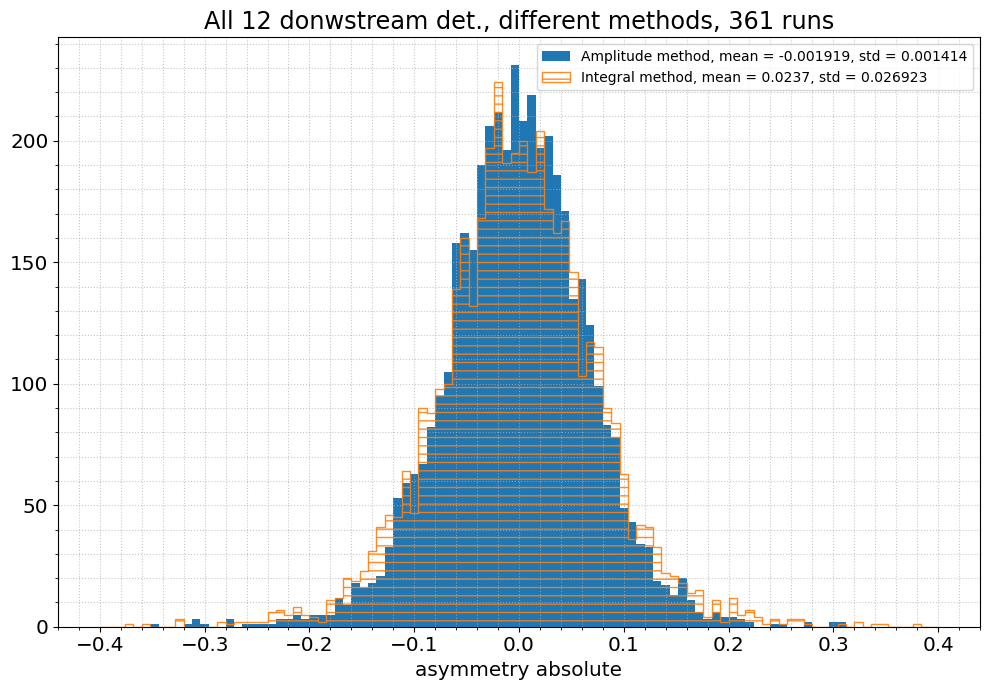

4332


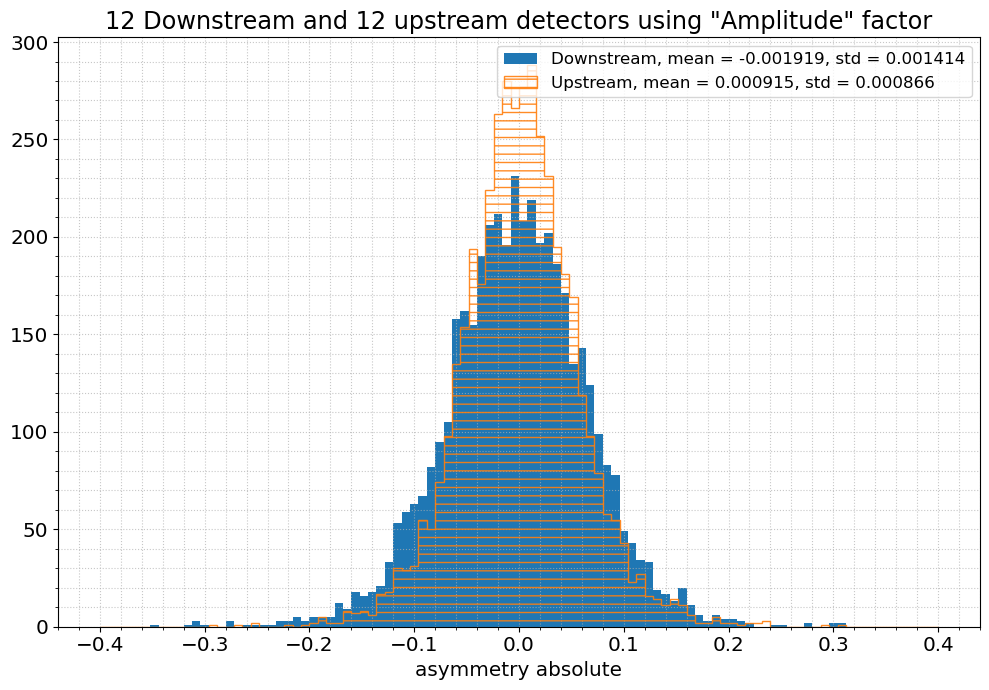

In [42]:
## upstream / downstream 

%matplotlib inline
r = [-0.4,0.4]
b = 100
all_amp_norm_D = (all_amp_D/all_sequences).flatten()
all_integral_norm_D = (all_integral_D/all_sequences).flatten()
print(len(all_amp_norm_D), len(all_integral_norm_D))
mean = np.round(np.mean(all_amp_norm_D),6)
std = np.round(np.std(all_amp_norm_D)/(np.sqrt(numruns_tot_D*12)),6)
mean2 = np.round(np.mean(all_integral_norm_D),6)
std2 = np.round(np.std(all_integral_norm_D)/(np.sqrt(numruns_tot_D*12)),6)

plt.hist(all_amp_norm_D, bins=b,range=r, label = f'Amplitude method, mean = {mean}, std = {std}')
plt.hist(all_integral_norm_D, bins=b,range=r, label = f'Integral method, mean = {mean2}, std = {std2}', alpha =0.9, hatch='--',histtype='step')
# plt.figure()
# plt.hist(all_integral_norm[ch+1], bins =bval, range = r, alpha =0.9, hatch='--',histtype='step', label = channels_all[ch+1]+f', mean = {mean2}, (plain) std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.title(f'All 12 donwstream det., different methods, {numruns_tot_D} runs', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend(fontsize = 'medium')
plt.show()

plt.figure()
all_amp_norm_U = (all_amp_U/all_sequences).flatten()
print(len(all_amp_norm_U))
mean_U = np.round(np.mean(all_amp_norm_U),6)
# std = np.round(np.std(all_amp_norm_U),6)
std_U = np.round(np.std(all_amp_norm_U)/(np.sqrt(numruns_tot_U*12)),6)

# plt.hist(all_amp_norm_U, bins = b, range=r, label = rf'mean = {mean}, std = {std}')
plt.hist(all_amp_norm_D, bins=b,range=r, label = f'Downstream, mean = {mean}, std = {std}')
plt.hist(all_amp_norm_U, bins=b,range=r, label = f'Upstream, mean = {mean_U}, std = {std_U}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'12 Downstream and 12 upstream detectors using "Amplitude" factor', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

(24, 361)
[ 0.035702 -0.032983 -0.001645 ...  0.062975  0.036337  0.069724]
(8663,)
[ 0.092597  0.036626 -0.022376  0.039252  0.019938 -0.057198  0.111928
 -0.047531  0.004899 -0.04808   0.036514 -0.038382  0.039234  0.009252
  0.02489   0.03801  -0.026336  0.034554  0.120084  0.042628  0.110734
  0.02097   0.042196  0.007969]
[23]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
-0.2881131357303542
-0.006257492831673098
0.07560085977683108


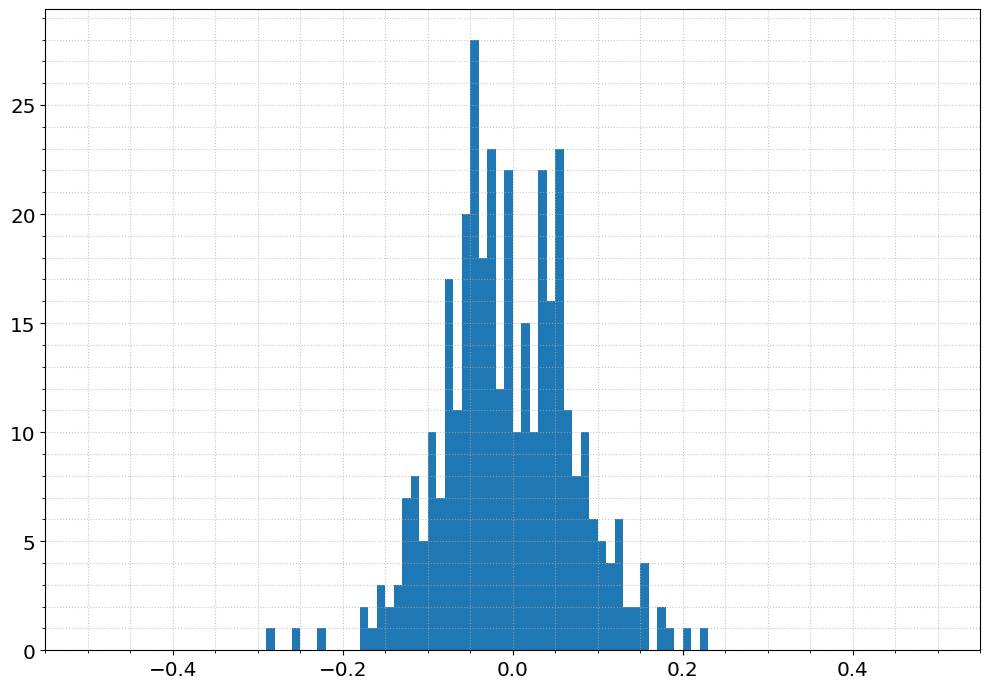

In [43]:
# print(all_amp_norm.shape)
# print(all_amp_norm[6][50:60])

# print(all_amp_norm[[0,3,6,9,12,15,18,21]][50:60])

corners = [0,3,6,9,12,15,18,21]
corner_amp_norm = np.asarray(all_amp_norm[corners])
# print(corner_amp_norm.shape)
print(all_amp_norm.shape)
print(np.delete(all_amp_norm[:],7))
print(np.delete(all_amp_norm[::],7).shape)
# print(corner_amp_norm[2][50:60])
print(all_amp_norm[:,7])

for i in range(0,24):
    # print(np.mean(all_amp_norm[i]))
    z = np.abs(st.zscore((all_amp_norm[i])))
    # print(z)
    threshold_z = 15
    outlier_indices = np.where(z > threshold_z)[0]
    print(outlier_indices)

print(np.min(all_amp_norm[18]))

# %matplotlib qt
plt.hist(all_amp_norm[18],bins=b,range=[-0.5,0.5], label = rf'Corner, mean = {mean}, plain std = {std}')
print(np.mean(all_amp_norm[18]))
print(np.std(np.delete(all_amp_norm[18],7)))

In [44]:
ch = 7
z = np.abs(stats.zscore(all_amp_norm[ch]))
# print(z)

threshold_z = 20

outlier_indices = np.where(z > threshold_z)[0]
print()
print(outlier_indices)
print(all_amp_norm[ch][105:115])
print(np.delete(all_amp_norm[ch], 7)[105:115])
print(all_amp_norm[ch][outlier_indices])
# no_outliers = df_diabetics.drop(outlier_indices)
# print("Original DataFrame Shape:", df_diabetics.shape)
# print("DataFrame Shape after Removing Outliers:", no_outliers.shape)

NameError: name 'stats' is not defined

In [ ]:
## corner v noncorner
%matplotlib inline
r = [-0.5,0.5]
b = 100

print(len(all_amp_norm))
# corners = [0,3,6,9] ## downstream (?)
corners = [0,3,6,9,12,15,18,21]
corner_amp_norm = np.asarray(all_amp_norm[corners]).flatten()
print(all_amp_norm[corners].shape, (corner_amp_norm.shape))
mean = np.round(np.mean(corner_amp_norm),7)
std = np.round(np.std(corner_amp_norm)/(np.sqrt(numruns_tot_D*len(corners))),7) ## len of corner_amp_norm = numruns*8 (8 corner)
# std = np.round(np.std(corner_amp_norm)/(np.sqrt(len(corner_amp_norm))),6) ## len of corner_amp_norm = numruns*8 (8 corner)

plt.hist(corner_amp_norm,bins=b,range=r, label = rf'Corner, mean = {mean}, plain std = {std}')

# noncorners = [1,2,4,5,7,8,10,11] ## downstream (?)
noncorners = [1,2,4,5,7,8,10,11,13,14,16,17,19,20,22,23]
noncorner_amp_norm = np.asarray(all_amp_norm[noncorners]).flatten()
print(all_amp_norm[noncorners].shape, (noncorner_amp_norm.shape))
# noncorner_amp_norm = noncorner_amp_norm[0].flatten()
print(len(noncorner_amp_norm))
mean2 = np.round(np.mean(noncorner_amp_norm),7)
std2 = np.round(np.std(noncorner_amp_norm)/(np.sqrt(numruns_tot_D*len(noncorners))),7) 
# std2 = np.round(np.std(noncorner_amp_norm)/(np.sqrt(len(noncorner_amp_norm))),6) 

plt.hist(noncorner_amp_norm,bins=b,range=r, label = rf'Non-corner, mean = {mean2}, plain std = {std2}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'Corner v. Non-corner detectors', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

In [ ]:
##left v right
## facing downstream towards beam-dump

%matplotlib inline
r = [-0.4,0.4]
b = 200

print(len(all_amp_norm))
# left = [0,3,6,9] ## downstream (?)
left = [3,4,5,6,12,23,22,21]
left_amp_norm = np.asarray(all_amp_norm[left]).flatten()
print(all_amp_norm[left].shape, (left_amp_norm.shape))
mean = np.round(np.mean(left_amp_norm),6)
std = np.round(np.std(left_amp_norm)/(np.sqrt(numruns_tot_D*8)),7) ## len of left_amp_norm = numruns*8 (8 left)
# std = np.round(np.std(left_amp_norm)/(np.sqrt(len(left_amp_norm))),6) ## len of left_amp_norm = numruns*8 (8 left)

plt.hist(left_amp_norm,bins=b,range=r, label = rf'left, mean = {mean}, plain std = {std}')

# right = [1,2,4,5,7,8,10,11] ## downstream (?)
right = [0,11,10,9,15,16,17,18]
right_amp_norm = np.asarray(all_amp_norm[right]).flatten()
print(all_amp_norm[right].shape, (right_amp_norm.shape))
# right_amp_norm = right_amp_norm[0].flatten()
print(len(right_amp_norm))
mean2 = np.round(np.mean(right_amp_norm),6)
std2 = np.round(np.std(right_amp_norm)/(np.sqrt(numruns_tot_D*8)),7) 
# std2 = np.round(np.std(right_amp_norm)/(np.sqrt(len(right_amp_norm))),6) 

plt.hist(right_amp_norm,bins=b,range=r, label = rf'Right, mean = {mean2}, plain std = {std2}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'left v. Right detectors', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

In [ ]:
##top v bottom

%matplotlib inline
r = [-0.35,0.35]
b = 200

print(len(all_amp_norm))
# top = [0,3,6,9] ## downstream (?)
top = [0,1,2,3,12,13,14,15]
top_amp_norm = np.asarray(all_amp_norm[top]).flatten()
print(all_amp_norm[top].shape, (top_amp_norm.shape))
mean = np.round(np.mean(top_amp_norm),6)
std = np.round(np.std(top_amp_norm),6) ## len of top_amp_norm = numruns*8 (8 top)
# std = np.round(np.std(top_amp_norm)/(np.sqrt(len(top_amp_norm))),6) ## len of top_amp_norm = numruns*8 (8 top)

plt.hist(top_amp_norm,bins=b,range=r, label = rf'top, mean = {mean}, plain std = {std}')

# bottom = [1,2,4,5,7,8,10,11] ## downstream (?)
bottom = [6,7,8,9,18,19,20,21]
bottom_amp_norm = np.asarray(all_amp_norm[bottom]).flatten()
print(all_amp_norm[bottom].shape, (bottom_amp_norm.shape))
# bottom_amp_norm = bottom_amp_norm[0].flatten()
print(len(bottom_amp_norm))
mean2 = np.round(np.mean(bottom_amp_norm),6)
std2 = np.round(np.std(bottom_amp_norm),6) 
# std2 = np.round(np.std(bottom_amp_norm)/(np.sqrt(len(bottom_amp_norm))),6) 

plt.hist(bottom_amp_norm,bins=b,range=r, label = rf'bottom, mean = {mean2}, plain std = {std2}', alpha =0.9, hatch='--',histtype='step')

plt.title(rf'top v. bottom detectors', fontsize = 'xx-large')
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

## Now with sequence loading

##### let's re-try with amplitues per sequence instead of per run, then run autocorr

In [ ]:
# import h5py
# import numpy as np
# import os

def loadrun_seq_asym(run_filename, processedpath):
    """
    Load per-sequence asymmetries from a single run file.
    Returns:
      seq_asym_per_channel: list of np.array, length = num_channels (D or U file),
                            each array length = N_seq for that run (usually 13)
    """
    run_path = os.path.join(processedpath, run_filename)
    seq_asym_per_channel = []

    with h5py.File(run_path, 'r') as f:
        channels = list(f.keys())
        numchannels = len(channels) - 1  # exclude ch_24

        for ch_name in channels:
            if ch_name == "ch_24" or ch_name == 'xs ':
                continue  # skip monitor

            ch_grp = f[ch_name]
            # Each channel has subgroups ON and OFF
            if "ON" not in ch_grp or "OFF" not in ch_grp:
                raise ValueError(f"Channel {ch_name} missing ON/OFF subgroups")

            # Extract + and - amplitudes
            A_plus = np.array(ch_grp["ON"]["parameters"])[:, 0]   # index 0 = amplitude
            A_minus = np.array(ch_grp["OFF"]["parameters"])[:, 0]

            # Compute asymmetry per sequence
            asym_seq = (A_plus - A_minus) / (A_plus + A_minus)

            seq_asym_per_channel.append(asym_seq)

    return seq_asym_per_channel


In [ ]:
def build_seq_series_per_channel(d_runs, u_runs, processedpath):
    """
    Accumulates per-sequence asymmetries for all runs and channels.
    d_runs: list of filenames for downstream runs
    u_runs: list of filenames for upstream runs
    processedpath: base directory path
    Returns:
      seq_series_per_channel: list of length 24, each a 1D np.array of all sequences.
    """
    D_total = 24
    seq_series_per_channel = [[] for _ in range(D_total)]

    # Downstream detectors (0–11)
    for run_file in d_runs:
        seq_run = loadrun_seq_asym(run_file, processedpath)
        for ch in range(len(seq_run)):
            seq_series_per_channel[ch].extend(seq_run[ch])

    # Upstream detectors (12–23)
    for run_file in u_runs:
        seq_run = loadrun_seq_asym(run_file, processedpath)
        for ch in range(len(seq_run)):
            seq_series_per_channel[ch+12].extend(seq_run[ch])

    # Convert lists to numpy arrays
    seq_series_per_channel = [np.array(ch_seq) for ch_seq in seq_series_per_channel]
    return seq_series_per_channel


In [ ]:
# r = -20
# print(foldersflat[r])
# print(flatrunslist_D[r])
# print(foldersflat[r] + flatrunslist_D[r])
# print(processed_path +foldersflat[r] + flatrunslist_D[r])
# test = foldersflat+flatrunslist_D
# print(test[r])
# test2 = np.char.add(foldersflat,'asym_swave_D/')
# print(test2[r])

In [ ]:
# Example lists of filenames (you already have flatrunslist_D / _U)
d_run_files = np.char.add(foldersflat,'asym_D/')+flatrunslist_D
u_run_files = np.char.add(foldersflat,'asym_U/')+flatrunslist_U
processed_path = root + processedfolder  # same base path you already use

seq_series_per_channel = build_seq_series_per_channel(
    d_run_files, u_run_files, processed_path
)

# Inspect the shape
for d, arr in enumerate(seq_series_per_channel):
    print(f"Detector {d}: shape {arr.shape}")
seq_series_per_channel = np.array(seq_series_per_channel)

In [ ]:
## now that it is shown that autocor is 0 for sequences, do an equivalent asym, but with weights of 1, because we have individual asymm

def w_asym(asym_array, weights=None, N_input=None):
    # Handle 1D detector input
    single_channel = False
    if asym_array.ndim == 1:
        single_channel = True
        asym_array = asym_array[None, :]  # shape (1, M)

    D, M = asym_array.shape  # detectors × measurements

    # Default: equal weights = 1
    if weights is None:
        weights = np.ones(M)
    weights = np.asarray(weights, dtype=float)

    # Normalize and totals
    N_s = np.sum(weights)
    N_tot = D * N_input if N_input is not None else D * N_s

    # Weighted mean per detector
    weighted_sum = np.sum(asym_array * weights[None, :], axis=1)
    mu_det = weighted_sum / N_s

    # Weighted variance per detector
    resid = asym_array - mu_det[:, None]
    S_d = np.sum(weights[None, :] * resid**2, axis=1)
    sigma2_d = S_d / N_s
    se_det = np.sqrt(sigma2_d / N_input) if N_input else np.sqrt(sigma2_d / N_s)

    if single_channel:
        return mu_det[0], se_det[0]

    # Combined (ensemble) mean and SE
    mu_total = np.sum(weighted_sum) / (D * N_s)
    resid_total = asym_array - mu_total
    S_total = np.sum(weights[None, :] * resid_total**2)
    sigma2_total = S_total / (D * N_s)
    se_total = np.sqrt(sigma2_total / N_tot)
    return mu_total, se_total


In [ ]:

# -------------- load data --------------
Nr = np.asarray(all_sequences, dtype =np.int32)   # shape (R,)
A = all_amp  # shape (D, R)
print(type(Nr[0]), type(A[0][0]))
D, R = A.shape
N_seq = int(Nr.sum())

# choose detector (zero-based index)
det = 5

# -------------- flatten per-sequence series --------------
per_run = A[det]                # length R
run_series = all_amp[det]

# -------------- autocorr estimator (normalized) --------------
def autocorr_rho_full(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_lag is None or max_lag > n-1:
        max_lag = n-1
    xm = x - x.mean()
    denom = np.sum(xm * xm)
    corr_full = np.correlate(xm, xm, mode='full')
    corr = corr_full[n-1:n+max_lag+1]    # lags 0..max_lag
    rho = corr / denom
    return rho  # rho[0] = 1

max_lag = min(2000, N_seq-1)
# rho = autocorr_rho_full(run_series, max_lag=max_lag)
rho = autocorr_rho_full(seq_series_per_channel[det], max_lag=max_lag) ## uses all sequences individually organized

# -------------- cutoff rule (first negative or below noise) --------------
noise_level = 2.0 / math.sqrt(N_seq)
cutoff = max_lag
for k in range(1, len(rho)):
    if rho[k] < 0 or rho[k] < noise_level:
        cutoff = k-1
        break

# -------------- tau, Neff --------------
if cutoff >= 1:
    tau_sum = 1.0 + 2.0 * np.sum(rho[1:cutoff+1])
else:
    tau_sum = 1.0
Neff_sum = N_seq / tau_sum if tau_sum > 0 else 1.0
# Neff_sum = R / tau_sum if tau_sum > 0 else 1.0


# -------------- weighted std and SEs --------------
# weighted mean per-run for this detector:
# mu = np.average(per_run, weights=Nr)
mu, se = w_asym(seq_series_per_channel[det], weights=np.ones(seq_series_per_channel.shape[1]), N_input=seq_series_per_channel.shape[1])
var_w = np.sum(Nr * (per_run - mu)**2) / N_seq
sigma_w = math.sqrt(var_w)

SE_seq = sigma_w / math.sqrt(N_seq)
SE_run = sigma_w / math.sqrt(R)
SE_neff = sigma_w / math.sqrt(Neff_sum)

# -------------- print results --------------
print("Detector:", det)
print("R (runs):", R)
print("N_seq (per detector):", N_seq)
print("rho1:", rho[1])
print("noise_level (2/sqrt(N)):", noise_level)
print("cutoff lag:", cutoff)
print("tau_sum (truncated):", tau_sum)
print("N_eff (truncated):", Neff_sum)
print(f'mu (weighted per-run mean): {mu:.7f}')
print("sigma_w (weighted std):", sigma_w)
print("SE_seq:", SE_seq)
print("SE_run:", SE_run)
print("SE_neff:", SE_neff)

# -------------- plot rho_k --------------
lags = np.arange(len(rho))
plt.figure(figsize=(9,3))
plt.plot(lags[:200], rho[:200], marker='.', markersize=4, linestyle='-')
# plt.axhline(noise_level, color='red', linestyle='--', label=f'noise level = {noise_level:.4f}')
plt.axhline(0, color='red', linestyle='--', label=r'$\hat\rho_k$ 0 level')
plt.axvline(cutoff, color='green', linestyle='--', label=f'cutoff = {cutoff}')
plt.xlabel('lag k')
plt.ylabel(r'$\hat\rho_k$')
plt.title(f'Autocorrelation $\hat\\rho_k$, det. {det}, {N_seq} individual sequences')
plt.xlim(-2, 30)
plt.legend()

# Create a text box next to the legend
textstr = f'$\\tau_{{sum}}$ = {tau_sum:.2f}\n$N_{{eff}}$ = {Neff_sum:.0f}'

# Get the legend box position
leg = plt.gca().get_legend()
if leg:
    bbox = leg.get_frame().get_bbox()
    x0 = bbox.x1 - 0.05  # small offset to the right of legend
    y0 = bbox.y0 + 0.05
else:
    x0, y0 = 0.8, 0.8  # fallback position

# Place the annotation box
plt.gca().text(0.8, 0.9, textstr, transform=plt.gca().transAxes,
               fontsize=10, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='whitesmoke', alpha=0.8))

plt.tight_layout()
plt.show()

In [ ]:
# -------------- weighted std and SEs --------------
# weighted mean per-run for this detector:
# mu = np.average(per_run, weights=Nr)
mu, se = w_asym(seq_series_per_channel[det], weights=np.ones(seq_series_per_channel.shape[1]), N_input=seq_series_per_channel.shape[1])
var_w = np.sum(Nr * (per_run - mu)**2) / N_seq
sigma_w = math.sqrt(var_w)

SE_seq = sigma_w / math.sqrt(N_seq)
SE_run = sigma_w / math.sqrt(R)
SE_neff = sigma_w / math.sqrt(Neff_sum)

In [ ]:
# print('1. using old [DxR] array of asymmetries with all_sequences weights (Num. of sequences length R) and N=N_seq:')
# mu_old, se_old = w_asym(all_amp, weights=all_sequences, N_input=np.sum(all_sequences))
# print(mu_old, '+/-', se_old, '\n')
print('1. using old [DxR] array of asymmetries with all_sequences weights (Num. of sequences length R) and N=N_r:')
mu_old, se_old = w_asym(all_amp, weights=all_sequences, N_input=N_r)
print(mu_old, '+/-', se_old, '\n')
print('2. using new [DxS] of asymmetries array with equal weights of 1 and N=N_seq:')
seq_series_per_channel = np.array(seq_series_per_channel)
mu, se = w_asym(seq_series_per_channel, weights=np.ones(seq_series_per_channel.shape[1]), N_input=seq_series_per_channel.shape[1])
print(mu, '+/-', se)

In [ ]:
ch = 1
r = 100
print(seq_series_per_channel[ch][13*r:13*r+13])
print(np.sum(seq_series_per_channel[ch][13*r:13*r+13]))
print(all_amp[ch][r])

In [ ]:
mean_all_r, se_all_r = w_asym(all_amp, weights=all_sequences, N_input=N_r)
print(mean_all_r, se_all_r, '\n')
mean_all_seq_new, se_all_seq_new = w_asym(seq_series_per_channel, weights=np.ones(seq_series_per_channel.shape[1]), N_input=seq_series_per_channel.shape[1])
print(mean_all_seq_new, se_all_seq_new, '\n')


In [ ]:
## all 24, amplitude separated into sequencces

%matplotlib inline
r = [-0.35,0.35]
b = 100

mu, se = w_asym(seq_series_per_channel, weights=np.ones(seq_series_per_channel.shape[1]), N_input=seq_series_per_channel.shape[1])

all_NaI_amp = all_amp_norm.flatten()
plt.title(rf'All 24 NaI detectors, organization by sequences', fontsize = 'xx-large')
mean = np.round(mu,7)
std = np.round(se,7)
mean2 = np.round(mean_all_r,7)
std2 = np.round(se_all_r,7)
# mean3 = np.round(mean_all_eff,7)
# std3 = np.round(se_all_eff,7)
# n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'mean = {mean}, $SE_{{seq}}$ = {std}\nmean = {mean2}, $SE_{{r}}$ = {std2} \nmean = {mean3}, $SE_{{eff}}$ = {std3}')
n_amp, bins_amp, patches_amp = plt.hist(all_NaI_amp,bins=b,range=r, label = f'mean = {mean}, $SE_{{seq}}$ = {std}\nmean = {mean2}, $SE_{{r}}$ = {std2}')

y_amp = n_amp
x = np.linspace(r[0],r[1], b)

popt_amp,pcov_amp=curve_fit(gauss,x,y_amp,p0=[700,0,150]) # popt= optimize parameter
# sig = 1/np.sqrt(y_amp)
sig = gauss(x, *popt_amp) - n_amp
# sig[sig == 0] = 1
# sig = None

chi2_amp = chi_square_dof(gauss,x,y_amp, popt_amp, sig)
print('chi square/dof for amp: ', chi2_amp[-1])
plt.plot(x,gauss(x,*popt_amp),color='red',lw=1.5,ls = '--',label=f'Gaussian fit mu={np.round(popt_amp[1],5)}, $\chi$/dof={np.round(chi2_amp[-1],4)}')
# plt.plot(x,gauss(x,*popt_amp),color='blue',lw=2.0,ls = '--',label=f'Amplitude Gaussian fit mu={np.round(popt_amp[1],5)}')

print('amp',popt_amp[0]) # amp
print('mean',popt_amp[1])# mean mu
print('sigma',popt_amp[2]) # sigma
plt.xlabel('asymmetry absolute')
plt.legend()
plt.show()

In [ ]:
print(np.abs(mu/se))
print(np.abs(mean2/std2))

In [ ]:
print(seq_series_per_channel.shape)

# ended here

#### original testing with weighted means, SE, etc.

In [ ]:
## according to mr. GPT

A = np.array(all_amp[1])          # your run sums (asymmetries)
n = np.array(all_sequences)          # your run sizes (sequences), e.g. mostly 13

K = len(A)
Ntot = n.sum()

m = A / n                # per-run mean per sequence
mu = A.sum() / Ntot      # weighted grand mean (per-sequence)

S = np.sum(n * (m - mu)**2)     # sum n_i*(m_i - mu)^2
sigma2_hat = S / (K - 1)        # unbiased estimator of per-sequence variance
SE_mu = np.sqrt(sigma2_hat / Ntot)

print("K =", K, "Ntot =", Ntot)
print("mu = {:.6e} ± {:.6e}".format(mu, SE_mu))

In [ ]:
# Suppose you have M=24 detectors, per-detector run-sums A_k_runs (shape M x K)
# and run sizes n_runs (length K). We compute per-detector per-seq variance sigma2_k,
# then a pooled sigma2_pooled and SE_combined assuming independence.

M = 24
A = all_amp   # shape (M, K) run sums per detector
n_runs = all_sequences  # shape (K,), sequences in each run (same for all detectors)

# per-detector grand mean and per-run means:
N_per_detector = n_runs.sum()           # this is your 'n' above
mk_runs = A / n_runs                    # shape (M, K)
mk = A.sum(axis=1) / N_per_detector     # per-detector weighted mean

# estimate per-detector per-sequence variance from run-compressed data
K = A.shape[1]
sigma2_k = np.zeros(M)
for k in range(M):
    mi = mk_runs[k, :]
    S = np.sum(n_runs * (mi - mk[k])**2)
    sigma2_k[k] = S / (K - 1)    # unbiased per-sequence var estimate for detector k

# pooled variance (if you assume detectors share same sigma^2)
sigma2_pooled = sigma2_k.mean()    # or a weighted average if preferred

# combined SE assuming detectors independent:
SE_combined = np.sqrt(sigma2_pooled / (N_per_detector * M))

# If you suspect correlations, compute empirical covariance of mk_runs across detectors
# and use Var(combined_mean) = (1/M^2) * 1^T Cov(mk) 1  (see earlier messages)

print(np.mean(A.flatten()))
print(sigma2_pooled, SE_combined)

In [26]:
## from chat
D, R = all_amp.shape

# Weighted mean per detector
w_mean_det_amp = np.sum(all_amp * all_sequences, axis=1) / np.sum(all_sequences)
w_mean_det_integral = np.sum(all_integral * all_sequences, axis=1) / np.sum(all_sequences)

# Weighted standard deviation per detector
w_var_det_amp = np.sum(all_sequences * (all_amp - w_mean_det_amp[:, None])**2, axis=1) / np.sum(all_sequences)
w_std_det_amp = np.sqrt(w_var_det_amp)  ## I think because the std is weighted, we can use SE for runs, i.e. /sqrt(R), because /sqrt(N) is already accounted for
# stderr_det_amp = w_std_det_amp / np.sqrt(len(all_sequences))  ## this assumes N_r runs
stderr_det_amp = w_std_det_amp / np.sqrt(np.sum(all_sequences))  ## this uses N_seq all sequences
print(w_mean_det_amp.shape, stderr_det_amp.shape)

w_var_det_integral = np.sum(all_sequences * (all_integral - w_mean_det_integral[:, None])**2, axis=1) / np.sum(all_sequences)
w_std_det_integral = np.sqrt(w_var_det_integral)
stderr_det_integral = w_std_det_integral / np.sqrt(len(all_sequences))
print(w_mean_det_integral.shape, stderr_det_integral.shape)

# Combined weighted mean (all detectors)
w_mean_all_amp = np.sum(all_amp * all_sequences) / (np.sum(all_sequences)*D)
w_var_all_amp = np.sum(all_sequences * (all_amp - w_mean_all_amp)**2) / (np.sum(all_sequences) * all_amp.shape[0])
w_std_all_amp = np.sqrt(w_var_all_amp)
# stderr_all_amp = w_std_all_amp / np.sqrt(all_amp.size) ## this assumes N_r runs
stderr_all_amp = w_std_all_amp / np.sqrt(np.sum(all_sequences)*all_amp.shape[0]) ## this uses N_seq all sequences

w_mean_all_integral = np.sum(all_integral * all_sequences) / np.sum(all_sequences)
w_var_all_integral = np.sum(all_sequences * (all_integral - w_mean_all_integral)**2) / np.sum(all_sequences)
w_std_all_integral = np.sqrt(w_var_all_integral)
stderr_all_integral = w_std_all_integral / np.sqrt(all_integral.size)

print(f"Weighted mean per detector: {w_mean_det_amp}")
print(f"Combined asymmetry (all 24 dets): {w_mean_all_amp:.6f} ± {stderr_all_amp:.6f}")
print(w_mean_det_amp.shape, stderr_det_amp.shape)
print(w_mean_all_amp.shape, stderr_all_amp.shape)

print(f"Weighted mean per detector: {w_mean_det_integral}")
print(f"Combined asymmetry (all 24 dets): {w_mean_all_integral:.6f} ± {stderr_all_integral:.6f}")
print(w_mean_det_integral.shape, stderr_det_integral.shape)
print(w_mean_all_integral.shape, stderr_all_integral.shape)


(24,) (24,)
(24,) (24,)
Weighted mean per detector: [-0.002511 -0.001633  0.000386 -0.001494 -0.001146 -0.002758  0.004615
  0.005249 -0.002404 -0.006081 -0.001498 -0.000962  0.000315  0.001566
 -0.003329 -0.006644  0.000311 -0.002174  0.00075   0.000206 -0.000939
 -0.004652  0.005202  0.000507]
Combined asymmetry (all 24 dets): -0.000797 ± 0.000168
(24,) (24,)
() ()
Weighted mean per detector: [-0.004409 -0.001833  0.001514 -0.002572 -0.001141 -0.004163  0.004925
  0.003671 -0.002695 -0.004924 -0.002698 -0.00027   0.00039   0.001895
 -0.00362  -0.006858  0.00001  -0.001463 -0.001826 -0.000961 -0.001231
 -0.002945  0.004485  0.000367]
Combined asymmetry (all 24 dets): -0.026353 ± 0.003273
(24,) (24,)
() ()


In [ ]:
# # Create sample arrays
# array1 = all_sequences
# array2 = all_amp

# # Save the arrays to an uncompressed .npz file
# np.savez('asym_all_detectors.npz', arr1=array1, arr2=array2)


In [213]:
# # Create sample arrays
# array1 = all_sequences
# array2 = all_amp

# # Save the arrays to an uncompressed .npz file
# np.savez('asym_all_detectors_lapwave.npz', arr1=array1, arr2=array2)

In [217]:
# print(seq_series_per_channel.shape)
# print(all_amp.shape)
# print(all_amp.shape[1]*13)

# np.savez('asym_all_detectors_lapwave_perseq.npz', arr1=seq_series_per_channel)

(24, 12377)
(24, 953)
12389


#### testing

8992


(-0.01, 4.0)

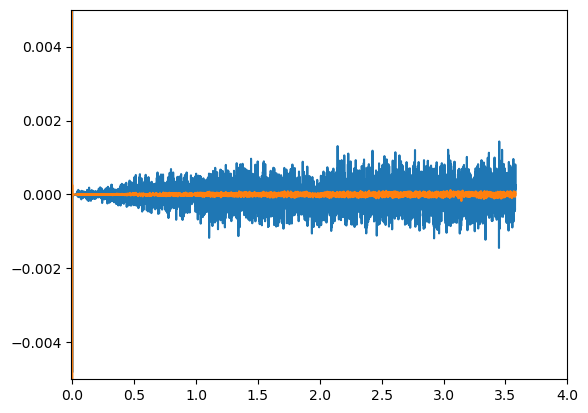

In [20]:
## what it looked like previous to deleting runs

allNaI_raw = np.sum(sum_ch_raw[3:5], axis = 0)
%matplotlib inline
print(len(allNaI_raw))
plt.plot(xs, sum_ch_raw[1]/np.sum(all_sequences))
plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.005, 0.005)
plt.xlim(-0.01, 4.0)

-0.07288897630071575


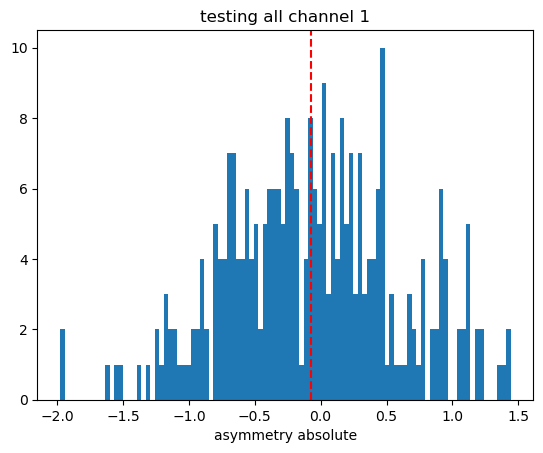

In [37]:
## idk what this is...

%matplotlib inline
ch = 1
plt.hist(all_amp[ch], bins = 100)
chmean = np.mean(all_amp[ch])
print(chmean)
plt.axvline(x=chmean,ls='--', c ='r')

plt.xlabel('asymmetry absolute')
plt.ylabel('')
plt.title(f'testing all channel {ch}')
# plt.legend()
plt.show()

In [31]:
# ## previously used for checking vstack

# %matplotlib inline
# # all_raw = np.vstack((all_raw_D,all_raw_U))
# # all_amp = np.vstack((all_amp_D,all_amp_U))
# # all_amp_norm = all_amp/all_sequences

# # plt.plot(xs, all_raw_D[-1][20])
# # plt.plot(xs, all_raw[11][20])
# plt.plot(xs, all_raw_U[-1][20])
# plt.plot(xs, all_raw[-1][20])
# plt.ylim(-100, 100)
# plt.xlim(-0.01, 3)
# # print(len(all_raw_D[0]))
# for i in range(0,12):
#     if all_raw_U[i][20][50] == all_raw[i+12][20][50]:
#         print('yay')
#     if all_raw_D[i][20][50] == all_raw[i][20][50]:
#         print('yay 2')
#     else: 
#         print('boo')
# # testrans = np.asarray(all_raw_D.transpose(1,0,2))
# # testranssum = np.sum(testrans[ch,:], axis = 0)
# # plt.plot(xs, testranssum)

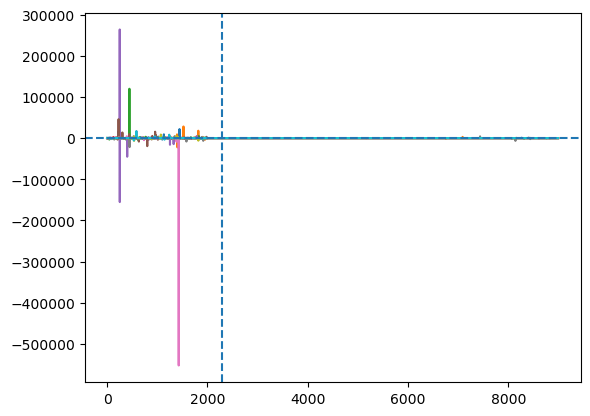

[[0, 3, 3, 6, 6, 7, 8, 9, 9, 11], [108, 108, 486, 108, 486, 108, 108, 108, 889, 108]]
[108 486 889]
(13, 952, 8992)
[108 486 889]
3
(13, 949, 8992)
25 24
8992
8992
[-0.0010873  -0.00086877 -0.00080156 -0.00060984 -0.00051714 -0.0007796
 -0.00055443 -0.00073349 -0.00059583 -0.00062426 -0.00088262 -0.0009591
 -0.00061495 -0.00093035 -0.00070578 -0.0007767  -0.00088883 -0.00080489
 -0.00070361 -0.00054328 -0.00078232 -0.00081491 -0.00050927 -0.00081126]


In [15]:
## testing for outlier runs
# ch = 0
# for ch in range(0, 1):
problem_files = [[],[]]
outlier_thresh = 50
start_b = 2300

for ch in range(0, len(all_raw_U)):
# for ch in range(0, 2):
    # plt.figure()
    for i in range(0, len(all_raw_U[0])):
        if np.max(np.abs(all_raw_U[ch,i,start_b:])) >= outlier_thresh:
            problem_files[0].append(ch)
            problem_files[1].append(i) 
            # print(ch, i, np.max(all_raw_U[ch,i,2200:]))
            plt.plot(all_raw_U[ch,i])

plt.axvline(start_b, ls = '--')
plt.axhline(outlier_thresh, ls = '--')
plt.show()
print(problem_files)
print(np.unique(np.sort(problem_files[1])))

print(all_raw_U.shape)
test_del = all_raw_U.copy()
test_prob_f = np.unique(np.sort(problem_files[1]))
print(test_prob_f)
print(len(test_prob_f))
test_new = np.delete(test_del, test_prob_f, axis=1)

print(test_new.shape)

%matplotlib qt
p = 0
plt.plot(all_raw_U[0][p], label='og')
plt.plot(all_raw_U[0][p+1], label = 'og+1', ls ='-.')
plt.plot(test_new[0][p], label = 'test del p ', ls ='--')
plt.plot(test_new[0][p+1], label = 'test del p+1', ls ='--')

plt.ylim(-100, 100)
plt.legend()

# print(all_raw_U[0][0][2200:2205])
# print(all_raw_U[0,0:p+6,2200:2205])
# # print(all_raw_U[0][p-1][2200:2205])
# # print(all_raw_U[0][p][2200:2205])
# # print(all_raw_U[0][p+1][2200:2205])
# # print(all_raw_U[0][p+2][2200:2205])
# # print(all_raw_U[0][p+3][2200:2205])
# # print(all_raw_U[0][p+4][2200:2205])
# print()
# # print(test_new[0][p-2][2200:2205])
# # print(test_new[0][p-1][2200:2205])
# # print(test_new[0][p][2200:2205])
# # print(test_new[0][p+1][2200:2205])
# # print(test_new[0][p+2][2200:2205])
# # print(test_new[0][p+3][2200:2205])
# # print(test_new[0][p+4][2200:2205])
# print(test_new[0,0:p+4,2200:2205])

sum_ch_raw = []
sum_ch_amp = []
p1 = 300
p2 = 400
for ch in range(0, len(all_raw)):
    chraw = np.sum(all_raw[ch,p1:p2], axis = 0)
    sum_ch_raw.append(chraw)
for ch in range(0, len(all_amp)):
    champ = np.sum(all_amp[ch,p1:p2], axis = 0)
    sum_ch_amp.append(champ)

sum_ch_raw = np.array(sum_ch_raw)
    
sum_ch_amp = sum_ch_amp/np.sum(all_sequences) ## normalize sum of amplitudes!
    
print(len(sum_ch_raw), len(sum_ch_amp))
print(len(sum_ch_raw[0]))
allNaI_raw = np.sum(sum_ch_raw[0:23], axis = 0)

%matplotlib qt
print(len(allNaI_raw))
plt.plot(xs, sum_ch_raw[2]/np.sum(all_sequences))
# plt.plot(xs, allNaI_raw/np.sum(all_sequences)/24)
plt.ylim(-0.02, 0.02)
plt.xlim(-0.01, 3.5)
# print(len(all_raw_D[0]))
print(sum_ch_amp)

### paper plotting

# only run once!

### plotting for paper

## See 05.05.25 file for plotting, not here!

In [16]:
from functools import reduce
def factors(n):
    return set(reduce(list.__add__,([i, n//i] for i in range(1, int(n**0.5) + 1) if n % i == 0)))

def rebin(ys, xs, rebinfactor):
    outys = ys.reshape(-1, rebinfactor).mean(axis=1)
    outxs = xs.reshape(-1, rebinfactor).mean(axis=1)
    return outys, outxs

# rebinf = rebinfactors[6]
# print(f'using factor {rebinf}')
# y2_rebin, x_rebin = rebin(y2, x, rebinf)


In [21]:
pulseadd_D = np.sum(all_D[:], axis = 1)

# Sample data
# r = 550
r1 = 2001
r2 = 8501

ch = 1
x = xs[r1:r2]
y1 = pulseadd_D[ch][r1:r2]
# y2 = allNaI_raw[r1:r2]/np.sum(all_sequences)/24*-1 ## flip the sign for plotting
y2 = sum_ch_raw[ch][r1:r2]/np.sum(all_sequences)*-1 ## flip the sign for plotting

rebinfactors = np.sort(np.array(list(factors(len(y2)))))
print(f'possible factors are ', rebinfactors)

rebinf = rebinfactors[5]
print(f'using factor {rebinf}')

y2_rebin, x_rebin = rebin(y2, x, rebinf)

possible factors are  [   1    2    4    5   10   13   20   25   26   50   52   65  100  125
  130  250  260  325  500  650 1300 1625 3250 6500]
using factor 13


In [28]:
from cycler import cycler
import matplotlib as mpl

# Set a colorblind-friendly categorical color cycle
mpl.rcParams['axes.prop_cycle'] = cycler(color=[
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#F0E442',  # Yellow
    '#56B4E9',  # Light Blue
])

plt.rcParams.update({
    'font.size': 8,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'text.usetex': False,
    'figure.figsize': (3.5, 2.7),
    'figure.dpi': 300,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'lines.linewidth': 0.8,
    'lines.markersize': 3.0,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'grid.linewidth': 0.5,
})
print('updated rcparams')

updated rcparams


### end paper plotting